<a href="https://colab.research.google.com/github/kassmontezuma/Capstone/blob/DeepLearning/EntrenamientoDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git clone https://github.com/kassmontezuma/Capstone.git

Cloning into 'Capstone'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 157 (delta 41), reused 117 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (157/157), 26.44 MiB | 13.36 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [4]:
%cd Capstone
!git branch -a
!git checkout DeepLearning

/content/Capstone
* main
  remotes/origin/DeepLearning
  remotes/origin/HEAD -> origin/main
  remotes/origin/dataset2
  remotes/origin/dataset2FinalSinVerificar
  remotes/origin/main
  remotes/origin/mlEDAFinal
Branch 'DeepLearning' set up to track remote branch 'DeepLearning' from 'origin'.
Switched to a new branch 'DeepLearning'


In [5]:
!git config --global user.email "kassymontezuma@gmail.com"
!git config --global user.name "Kassandra"

In [7]:
!git status

On branch DeepLearning
Your branch is up to date with 'origin/DeepLearning'.

nothing to commit, working tree clean


# Librerias

In [49]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
import torchvision.models as models
from torchvision.models import MobileNet_V2_Weights
from torchvision.models import DenseNet121_Weights
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Configuración

In [5]:
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

# Fijar semillas para reproducibilidad
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


# Montar drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cargar dataset

In [7]:
train_df = pd.read_csv("train_dataset.csv")
val_df = pd.read_csv("val_dataset.csv")
test_df = pd.read_csv("test_dataset.csv")

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 3307
Val size: 688
Test size: 685


# Corregir rutas

In [8]:
PATCH_DIR = "/content/drive/MyDrive/INTRUSA JIJIJI/patches_candidates"
train_df['path'] = train_df['path'].apply(
    lambda x: os.path.join(
        PATCH_DIR,
        os.path.basename(x.replace("\\", "/"))
    )
)
val_df['path'] = val_df['path'].apply(
    lambda x: os.path.join(
        PATCH_DIR,
        os.path.basename(x.replace("\\", "/"))
    )
)
test_df['path'] = test_df['path'].apply(
    lambda x: os.path.join(
        PATCH_DIR,
        os.path.basename(x.replace("\\", "/"))
    )
)
print(train_df.iloc[0]['path'])

/content/drive/MyDrive/INTRUSA JIJIJI/patches_candidates/1.3.6.1.4.1.14519.5.2.1.6279.6001.306140003699110313373771452136_363616_label0.npy


# Dataset class



In [9]:
class LungCancerDataset(Dataset):
    def __init__(self, dataframe, patch_size=(64, 64, 64), target_size=(224, 224)):
        self.df = dataframe
        self.patch_size = patch_size
        self.target_size = target_size

        # Normalización para redes pre-entrenadas (ImageNet stats)
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Cargar patch 3D
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        #Verifica que el archivo existe
        if not os.path.exists(path):
            print(f"Archivo no encontrado: {path}")
            # Retornar un patch dummy (esto no debería pasar si las rutas están bien)
            dummy_patch = np.zeros((64, 64, 64), dtype=np.float32)
            patch = dummy_patch
        else:
            patch = np.load(path)

        # 2. Extraer slices centrales de los 3 planos
        z_center, y_center, x_center = patch.shape[0]//2, patch.shape[1]//2, patch.shape[2]//2

        axial_slice = patch[z_center, :, :]      # plano axial (horizontal)
        coronal_slice = patch[:, y_center, :]    # plano coronal (frontal)
        sagital_slice = patch[:, :, x_center]    # plano sagital (lateral)

        # 3. Convertir a uint8 (0-255) para redimensionamiento con OpenCV
        # Porque tus valores están en [0,1] después del preprocessing
        axial = (axial_slice * 255).astype(np.uint8)
        coronal = (coronal_slice * 255).astype(np.uint8)
        sagital = (sagital_slice * 255).astype(np.uint8)

        # 4. Redimensionar a target_size (224x224)
        axial_resized = cv2.resize(axial, self.target_size, interpolation=cv2.INTER_LINEAR)
        coronal_resized = cv2.resize(coronal, self.target_size, interpolation=cv2.INTER_LINEAR)
        sagital_resized = cv2.resize(sagital, self.target_size, interpolation=cv2.INTER_LINEAR)

        # 5. Normalizar a [0,1] nuevamente (para convertir a tensor después)
        axial_norm = axial_resized / 255.0
        coronal_norm = coronal_resized / 255.0
        sagital_norm = sagital_resized / 255.0

        # 6. Stack como canales RGB (3, H, W)
        image = np.stack([axial_norm, coronal_norm, sagital_norm], axis=0)  # (3, 224, 224)

        # 7. Convertir a tensor y aplicar normalización ImageNet
        image = torch.from_numpy(image).float()
        image = self.normalize(image)

        # 8. Label (para clasificación binaria)
        label = torch.tensor(float(label), dtype=torch.float32)

        return image, label

# Crear datasets

In [10]:
train_dataset = LungCancerDataset(train_df)
val_dataset = LungCancerDataset(val_df)
test_dataset = LungCancerDataset(test_df)

# Verificar sizes
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 3307
Val size: 688
Test size: 685


# Verificar rutas

In [11]:
def check_paths(df, name):
    missing = 0
    for idx, row in df.iterrows():
        if not os.path.exists(row['path']):
            missing += 1
            print(f"Missing: {row['path']}")
    print(f"{name}: {missing} archivos faltantes de {len(df)}")
    return missing

print("\nVerificando rutas...")
missing_train = check_paths(train_df, "Train")
missing_val = check_paths(val_df, "Val")
missing_test = check_paths(test_df, "Test")

if missing_train + missing_val + missing_test > 0:
    print("\nHay archivos faltantes. Revisa tus rutas en Drive.")
else:
    print("\nTodas las rutas son correctas!")


Verificando rutas...
Train: 0 archivos faltantes de 3307
Val: 0 archivos faltantes de 688
Test: 0 archivos faltantes de 685

Todas las rutas son correctas!


# Ejemplito


Ejemplo de datos:
  - Imagen shape: torch.Size([3, 224, 224])
  - Label: 0.0
  - Rango: [-2.12, 2.61]


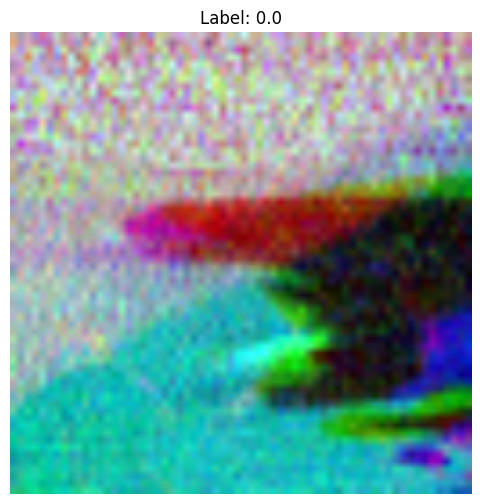

In [12]:
sample_image, sample_label = train_dataset[0]
print(f"\nEjemplo de datos:")
print(f"  - Imagen shape: {sample_image.shape}")
print(f"  - Label: {sample_label}")
print(f"  - Rango: [{sample_image.min():.2f}, {sample_image.max():.2f}]")

def imshow(tensor, title=None):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    npimg = tensor.numpy().transpose(1,2,0)
    plt.imshow(npimg)
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(6,6))
imshow(sample_image, f"Label: {sample_label.item()}")
plt.show()

# Crear dataloaders

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders creados exitosamente")
print(f"  - Batches por epoch (train): {len(train_loader)}")
print(f"  - Batches por epoch (val): {len(val_loader)}")



DataLoaders creados exitosamente
  - Batches por epoch (train): 104
  - Batches por epoch (val): 22


# Probar un batch


Batch test:
  - Images shape: torch.Size([32, 3, 224, 224])
  - Labels shape: torch.Size([32])
  - Labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
  - Image range: [-2.12, 2.64]


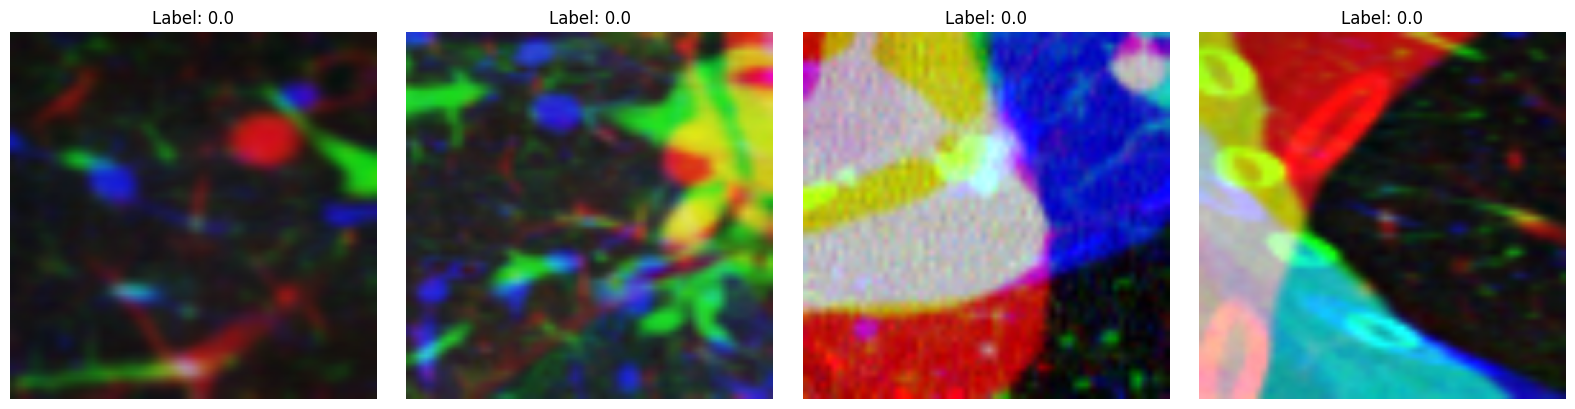

In [14]:
images, labels = next(iter(train_loader))
print(f"\nBatch test:")
print(f"  - Images shape: {images.shape}")  # [32, 3, 224, 224]
print(f"  - Labels shape: {labels.shape}")  # [32]
print(f"  - Labels: {labels[:10]}")
print(f"  - Image range: [{images.min():.2f}, {images.max():.2f}]")

# Visualizar primeras 4 imágenes del batch
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_display = images[i] * std + mean
    img_display = torch.clamp(img_display, 0, 1)

    axes[i].imshow(img_display.permute(1,2,0))
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()


# Sanity check


Verificando DataLoaders...
   Batch shape: torch.Size([32, 3, 224, 224])
   Labels shape: torch.Size([32])
   Image range: [-2.12, 2.64]
   Label values: tensor([0., 1.])

Verificando balance de clases...
   Train - Positivos: 862/3307 (26.1%)
   Train - Negativos: 2445/3307 (73.9%)
   Val   - Positivos: 188/688 (27.3%)
   Test  - Positivos: 170/685 (24.8%)

Visualizando ejemplo de datos...


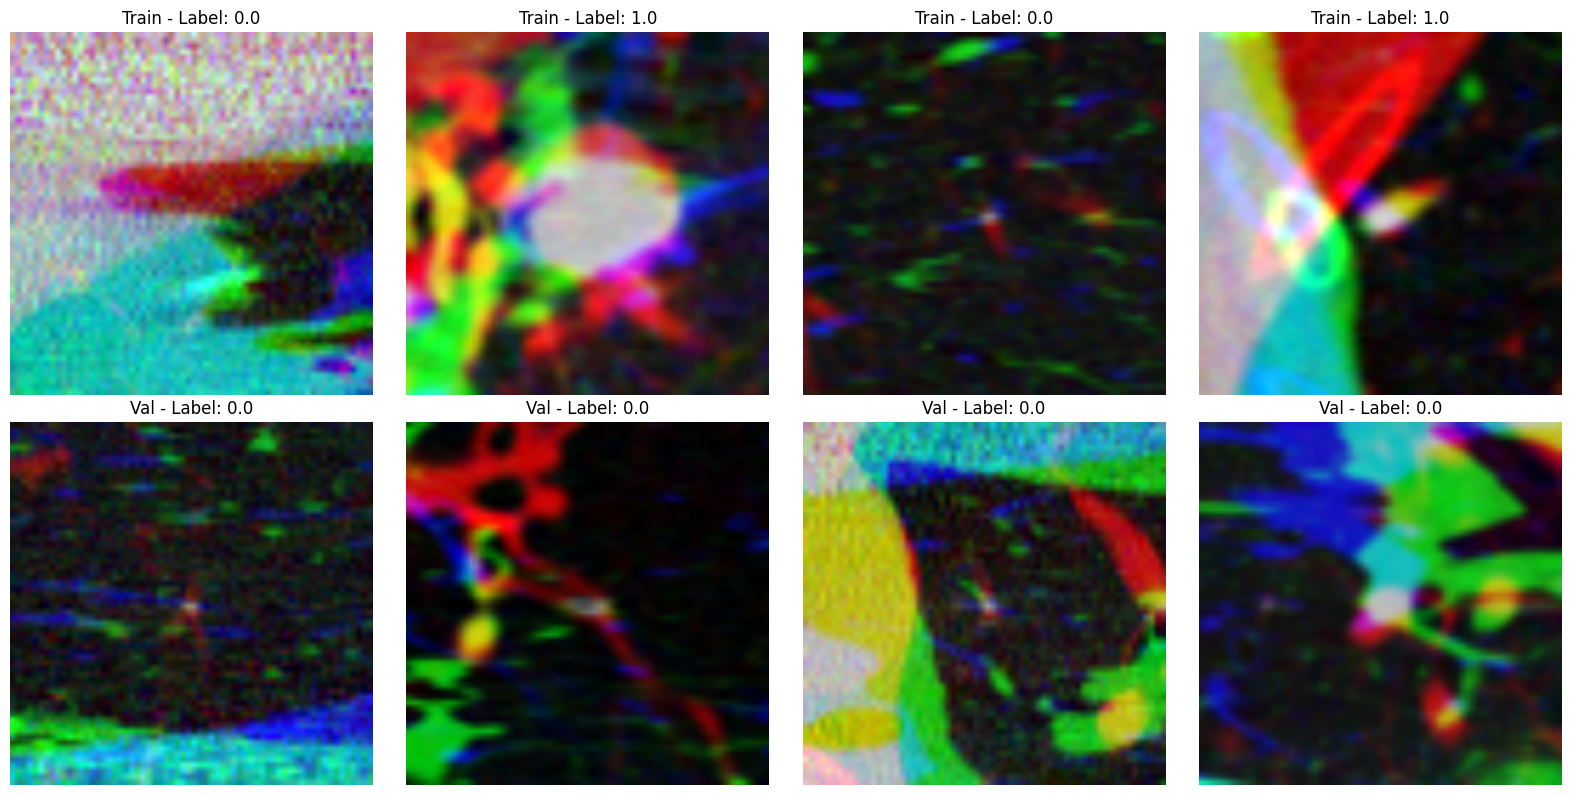


RESUMEN:
   - Device: cuda
   - Batch size: 32
   - Train samples: 3307
   - Val samples: 688
   - Test samples: 685
   - Clases balanceadas: 26.1% positivos

TODO LISTO PARA ENTRENAR LOS MODELOS


In [15]:
# 1. Verificar que los DataLoaders funcionan
print("\nVerificando DataLoaders...")
try:
    sample_batch_images, sample_batch_labels = next(iter(train_loader))
    print(f"   Batch shape: {sample_batch_images.shape}")
    print(f"   Labels shape: {sample_batch_labels.shape}")
    print(f"   Image range: [{sample_batch_images.min():.2f}, {sample_batch_images.max():.2f}]")
    print(f"   Label values: {torch.unique(sample_batch_labels)}")
except Exception as e:
    print(f"   Error: {e}")
    raise

# 2. Verificar distribución de clases
print("\nVerificando balance de clases...")
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
val_labels = [val_df.iloc[i]['label'] for i in range(len(val_df))]
test_labels = [test_df.iloc[i]['label'] for i in range(len(test_df))]

print(f"   Train - Positivos: {sum(train_labels)}/{len(train_labels)} ({100*sum(train_labels)/len(train_labels):.1f}%)")
print(f"   Train - Negativos: {len(train_labels)-sum(train_labels)}/{len(train_labels)} ({100*(len(train_labels)-sum(train_labels))/len(train_labels):.1f}%)")
print(f"   Val   - Positivos: {sum(val_labels)}/{len(val_labels)} ({100*sum(val_labels)/len(val_labels):.1f}%)")
print(f"   Test  - Positivos: {sum(test_labels)}/{len(test_labels)} ({100*sum(test_labels)/len(test_labels):.1f}%)")

# 3. Visualización de sanity check
print("\nVisualizando ejemplo de datos...")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Imagen de entrenamiento
    img, label = train_dataset[i]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img_display = img * std + mean
    img_display = torch.clamp(img_display, 0, 1)

    axes[0, i].imshow(img_display.permute(1,2,0))
    axes[0, i].set_title(f"Train - Label: {label.item()}")
    axes[0, i].axis('off')

    # Imagen de validación
    img_val, label_val = val_dataset[i]
    img_val_display = img_val * std + mean
    img_val_display = torch.clamp(img_val_display, 0, 1)

    axes[1, i].imshow(img_val_display.permute(1,2,0))
    axes[1, i].set_title(f"Val - Label: {label_val.item()}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("\nRESUMEN:")
print(f"   - Device: {DEVICE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Train samples: {len(train_dataset)}")
print(f"   - Val samples: {len(val_dataset)}")
print(f"   - Test samples: {len(test_dataset)}")

print(
    f"   - Clases balanceadas: "
    f"{100*sum(train_labels)/len(train_labels):.1f}% positivos"
)

print("\nTODO LISTO PARA ENTRENAR LOS MODELOS")

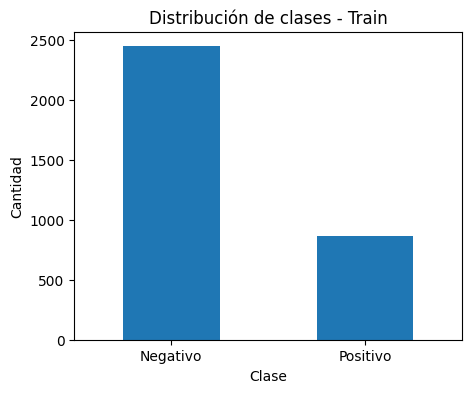

In [16]:
import matplotlib.pyplot as plt

counts = train_df['label'].value_counts()

plt.figure(figsize=(5,4))
counts.plot(kind='bar')
plt.title("Distribución de clases - Train")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks([0,1], ["Negativo", "Positivo"], rotation=0)
plt.show()

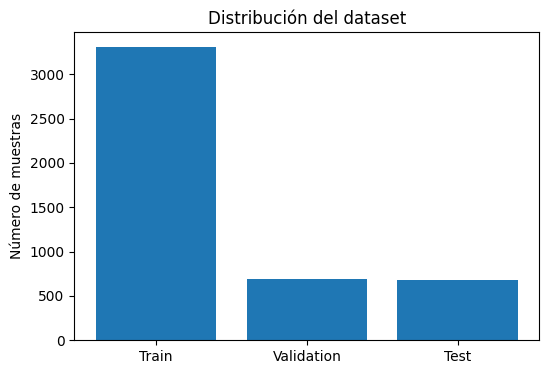

In [17]:
splits = [
    len(train_df),
    len(val_df),
    len(test_df)
]

labels = [
    "Train",
    "Validation",
    "Test"
]

plt.figure(figsize=(6,4))
plt.bar(labels, splits)
plt.title("Distribución del dataset")
plt.ylabel("Número de muestras")
plt.show()

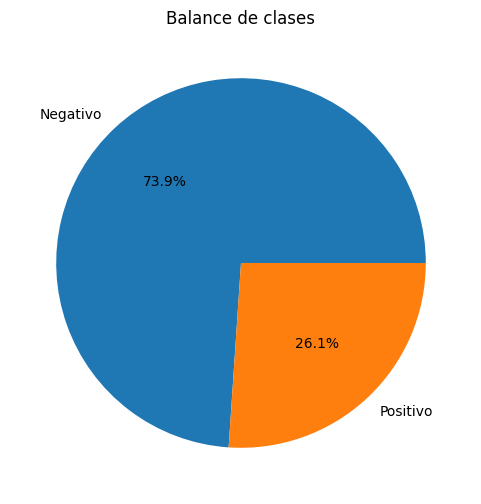

In [18]:
plt.figure(figsize=(6,6))

train_df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Negativo','Positivo']
)

plt.ylabel("")
plt.title("Balance de clases")
plt.show()

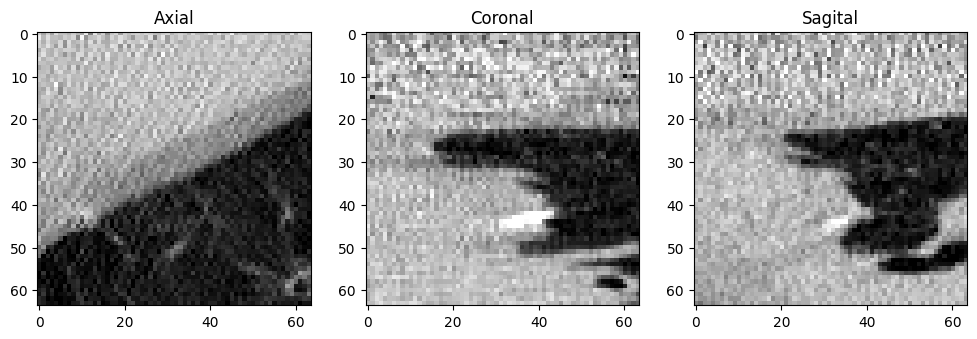

In [19]:
patch = np.load(train_df.iloc[0]['path'])

z_center = patch.shape[0] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(
    patch[z_center,:,:],
    cmap='gray'
)
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(
    patch[:,patch.shape[1]//2,:],
    cmap='gray'
)
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(
    patch[:,:,patch.shape[2]//2],
    cmap='gray'
)
plt.title("Sagital")

plt.show()

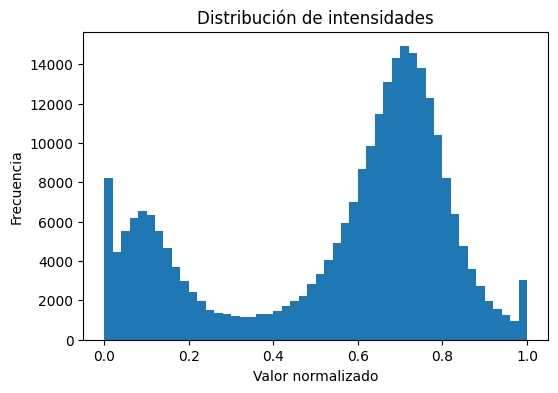

In [20]:
patch = np.load(train_df.iloc[0]['path'])

plt.figure(figsize=(6,4))

plt.hist(
    patch.flatten(),
    bins=50
)

plt.title("Distribución de intensidades")
plt.xlabel("Valor normalizado")
plt.ylabel("Frecuencia")

plt.show()

In [27]:
# Calcular el balance de clases en el dataset
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_negatives = train_labels.count(0)  # Clase negativa (sin cáncer)
num_positives = train_labels.count(1)  # Clase positiva (con cáncer)

print(f"Negativos (0): {num_negatives}")
print(f"Positivos (1): {num_positives}")
print(f"Ratio neg/pos: {num_negatives/num_positives:.2f}")

# pos_weight = #negativos / #positivos
pos_weight_value = num_negatives / num_positives
print(f"pos_weight sugerido: {pos_weight_value:.4f}")

# Crear criterio con pos_weight
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

Negativos (0): 2445
Positivos (1): 862
Ratio neg/pos: 2.84
pos_weight sugerido: 2.8364


# MOBILENETV2

In [31]:
def create_mobilenetv2():
    model = models.mobilenet_v2(
        weights=MobileNet_V2_Weights.IMAGENET1K_V1
    )

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, 1)
    )

    return model

# Wrapper para asegurar salida 1D
class MobileNetV2Classifier(nn.Module):
    def __init__(self):
        super(MobileNetV2Classifier, self).__init__()
        self.backbone = create_mobilenetv2()

    def forward(self, x):
        x = self.backbone(x)
        return x.squeeze(1)  # (batch, 1) -> (batch,)

# Crear instancia
model = MobileNetV2Classifier().to(DEVICE)

# Ver arquitectura
print("Arquitectura MobileNetV2:")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Probar forward pass
test_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = model(test_input)
print(f"\nTest forward: input shape {test_input.shape} -> output shape {test_output.shape}")

# Calcular pos_weight
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

print(f"\nBalance de clases:")
print(f"  Negativos (0): {num_neg}")
print(f"  Positivos (1): {num_pos}")
print(f"  pos_weight: {pos_weight_value:.4f}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"\nConfiguración:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Arquitectura MobileNetV2:
  Total parameters: 2,225,153
  Trainable parameters: 2,225,153

Test forward: input shape torch.Size([2, 3, 224, 224]) -> output shape torch.Size([2])

Balance de clases:
  Negativos (0): 2445
  Positivos (1): 862
  pos_weight: 2.8364

Configuración:
  Device: cuda
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 20


## Entrenamiento

In [32]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # Ahora ya es (batch,)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Precisión
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Ahora ya es (batch,)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


In [33]:
train_losses = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validar
    val_loss, val_acc, preds, labels, probs = validate_epoch(model, val_loader, criterion, DEVICE)

    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar historial
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
        }, 'best_mobilenetv2.pth')
        print(f"  Nuevo mejor modelo guardado (loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 7:
            print(f"  Early stopping en epoch {epoch+1}")
            break

    print("-" * 50)

print(f"\n🎉 Mejor modelo con val_loss: {best_val_loss:.4f}")


Epoch 1/20
  Train Loss: 0.6116 | Train Acc: 0.8101
  Val Loss:   0.3312 | Val Acc:   0.9128
  Precision: 0.8019 | Sensibilidad: 0.9043 | Especificidad: 0.9160 | F1: 0.8500
  Nuevo mejor modelo guardado (loss: 0.3312)
--------------------------------------------------

Epoch 2/20
  Train Loss: 0.2234 | Train Acc: 0.9516
  Val Loss:   0.2583 | Val Acc:   0.9419
  Precision: 0.9157 | Sensibilidad: 0.8670 | Especificidad: 0.9700 | F1: 0.8907
  Nuevo mejor modelo guardado (loss: 0.2583)
--------------------------------------------------

Epoch 3/20
  Train Loss: 0.0824 | Train Acc: 0.9834
  Val Loss:   0.3839 | Val Acc:   0.9491
  Precision: 0.9581 | Sensibilidad: 0.8511 | Especificidad: 0.9860 | F1: 0.9014
--------------------------------------------------

Epoch 4/20
  Train Loss: 0.0281 | Train Acc: 0.9970
  Val Loss:   0.3386 | Val Acc:   0.9477
  Precision: 0.9368 | Sensibilidad: 0.8670 | Especificidad: 0.9780 | F1: 0.9006
--------------------------------------------------

Epoch 5/2

## Visualización de resultados

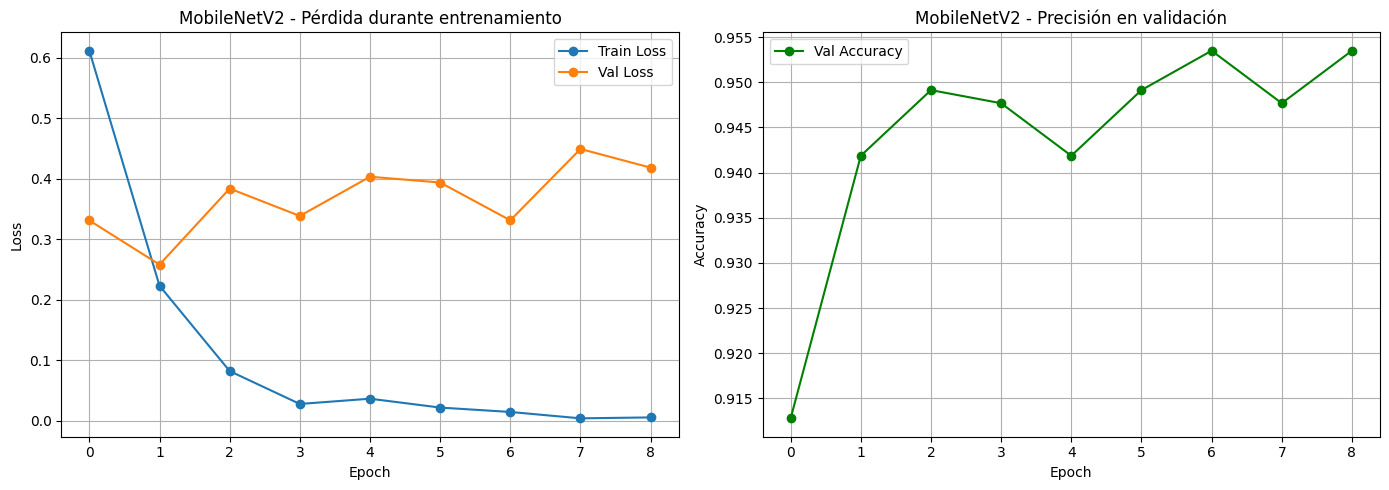

In [34]:
# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('MobileNetV2 - Pérdida durante entrenamiento')
axes[0].legend()
axes[0].grid(True)

# Gráfico de precisión
axes[1].plot(val_accuracies, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('MobileNetV2 - Precisión en validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

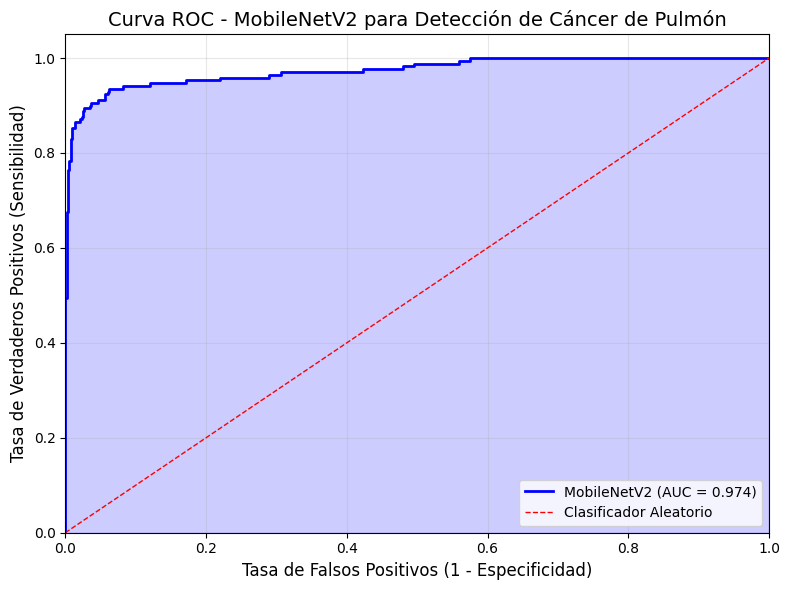

In [37]:
from sklearn.metrics import roc_curve, auc

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'MobileNetV2 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Clasificador Aleatorio')
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva ROC - MobileNetV2 para Detección de Cáncer de Pulmón', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

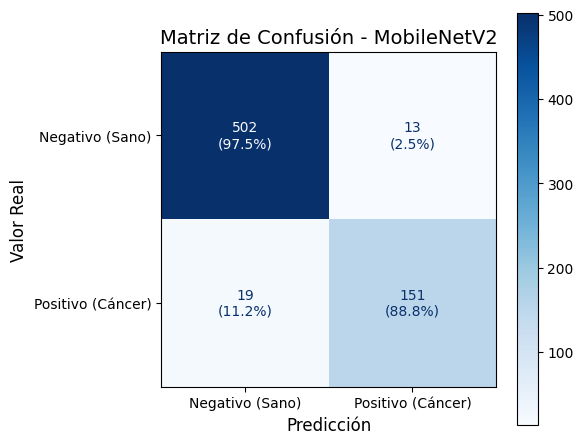

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
cm_display = ConfusionMatrixDisplay.from_predictions(
    test_labels, test_preds,
    display_labels=['Negativo (Sano)', 'Positivo (Cáncer)'],
    cmap='Blues',
    ax=ax
)

# Personalizar
ax.set_title('Matriz de Confusión - MobileNetV2', fontsize=14)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)

# Añadir porcentajes
for i in range(2):
    for j in range(2):
        text = ax.texts[i*2 + j]
        value = int(text.get_text())
        total = sum(cm_display.confusion_matrix[i])
        pct = (value / total) * 100 if total > 0 else 0
        text.set_text(f'{value}\n({pct:.1f}%)')

plt.tight_layout()
plt.show()

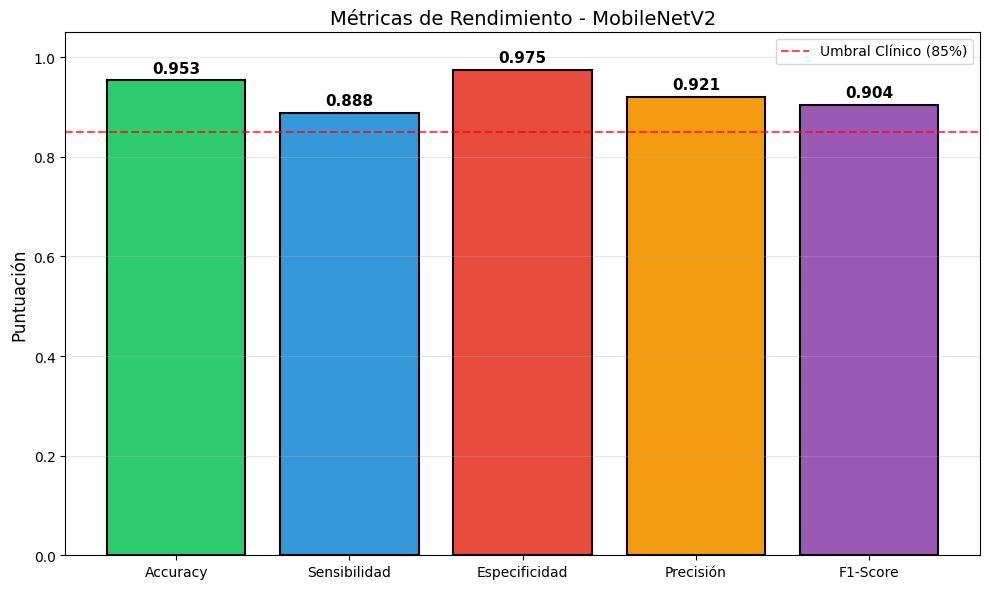

In [39]:
metrics = ['Accuracy', 'Sensibilidad', 'Especificidad', 'Precisión', 'F1-Score']
values = [0.9533, 0.8882, 0.9748, 0.9207, 0.9042]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Métricas de Rendimiento - MobileNetV2', fontsize=14)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='Umbral Clínico (85%)')

# Añadir valores en las barras
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

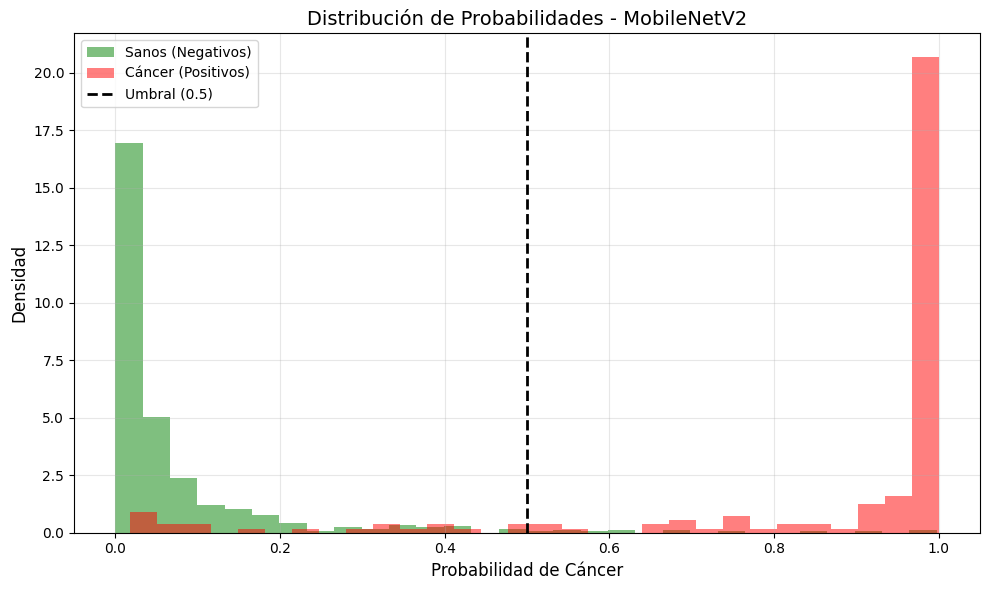

In [40]:
# Separar probabilidades por clase real
pos_probs = [test_probs[i] for i in range(len(test_labels)) if test_labels[i] == 1]
neg_probs = [test_probs[i] for i in range(len(test_labels)) if test_labels[i] == 0]

plt.figure(figsize=(10, 6))
plt.hist(neg_probs, bins=30, alpha=0.5, color='green', label='Sanos (Negativos)', density=True)
plt.hist(pos_probs, bins=30, alpha=0.5, color='red', label='Cáncer (Positivos)', density=True)
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral (0.5)')
plt.xlabel('Probabilidad de Cáncer', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title('Distribución de Probabilidades - MobileNetV2', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2364/4049554861.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Sanos\n(Negativos)', 'Cáncer\n(Positivos)'],


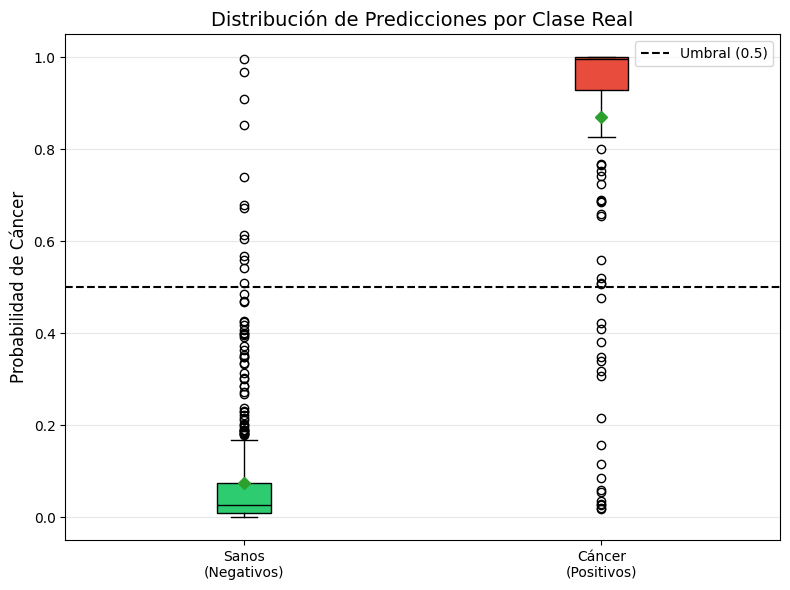

In [41]:
plt.figure(figsize=(8, 6))
data_to_plot = [neg_probs, pos_probs]
bp = plt.boxplot(data_to_plot, labels=['Sanos\n(Negativos)', 'Cáncer\n(Positivos)'],
                  patch_artist=True, showmeans=True)

# Colores
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
bp['medians'][0].set_color('black')
bp['medians'][1].set_color('black')
bp['means'][0].set_marker('D')
bp['means'][1].set_marker('D')

plt.ylabel('Probabilidad de Cáncer', fontsize=12)
plt.title('Distribución de Predicciones por Clase Real', fontsize=14)
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral (0.5)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

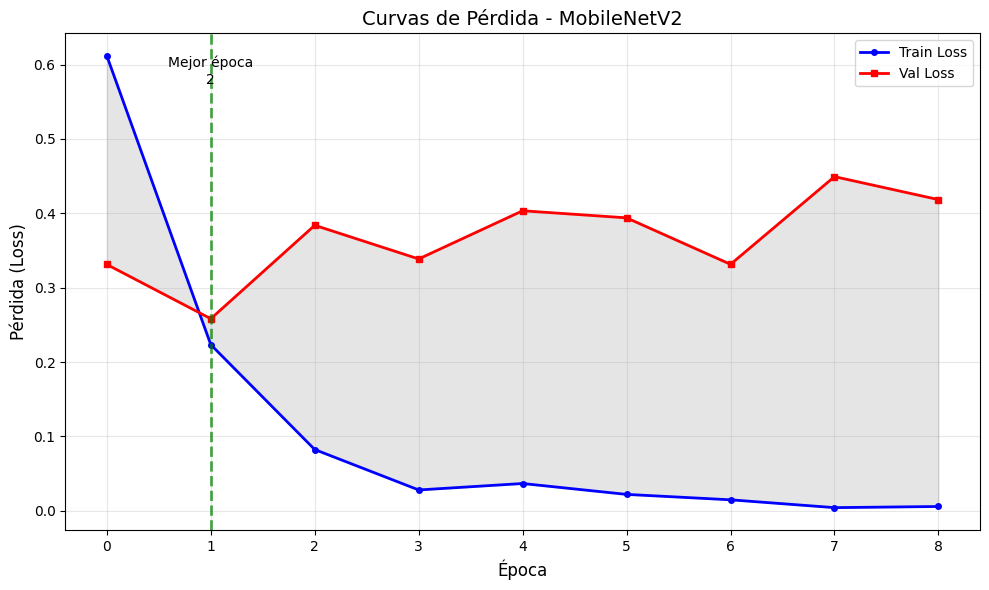

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

# Pérdida de entrenamiento
ax.plot(train_losses, 'b-', linewidth=2, label='Train Loss', marker='o', markersize=4)
ax.plot(val_losses, 'r-', linewidth=2, label='Val Loss', marker='s', markersize=4)

# Rellenar área entre curvas
ax.fill_between(range(len(train_losses)), train_losses, val_losses, alpha=0.2, color='gray')

# Marcar mejor época
best_epoch = val_losses.index(min(val_losses))
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.text(best_epoch, max(train_losses), f'Mejor época\n{best_epoch+1}',
        ha='center', va='top', fontsize=10)

ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Pérdida (Loss)', fontsize=12)
ax.set_title('Curvas de Pérdida - MobileNetV2', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

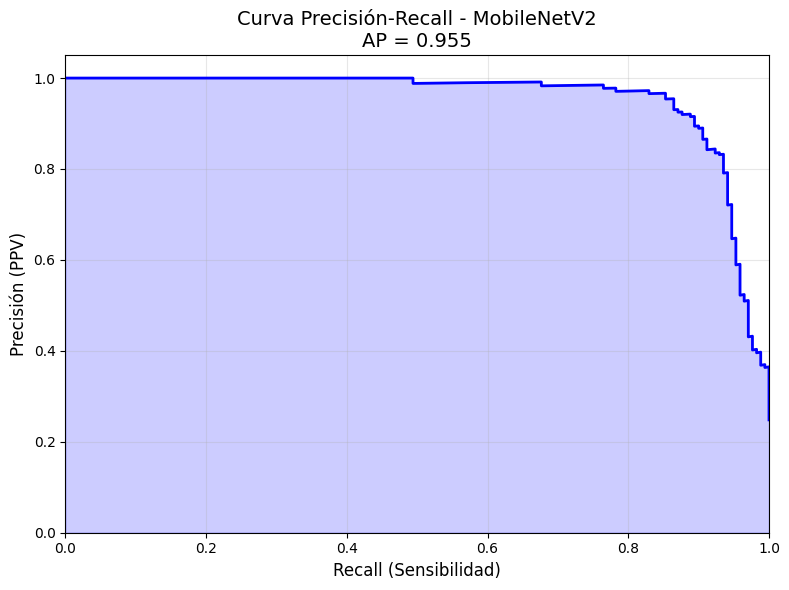

In [42]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(test_labels, test_probs)
avg_precision = average_precision_score(test_labels, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, 'b-', linewidth=2)
plt.fill_between(recall_curve, precision_curve, alpha=0.2, color='blue')
plt.xlabel('Recall (Sensibilidad)', fontsize=12)
plt.ylabel('Precisión (PPV)', fontsize=12)
plt.title(f'Curva Precisión-Recall - MobileNetV2\nAP = {avg_precision:.3f}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

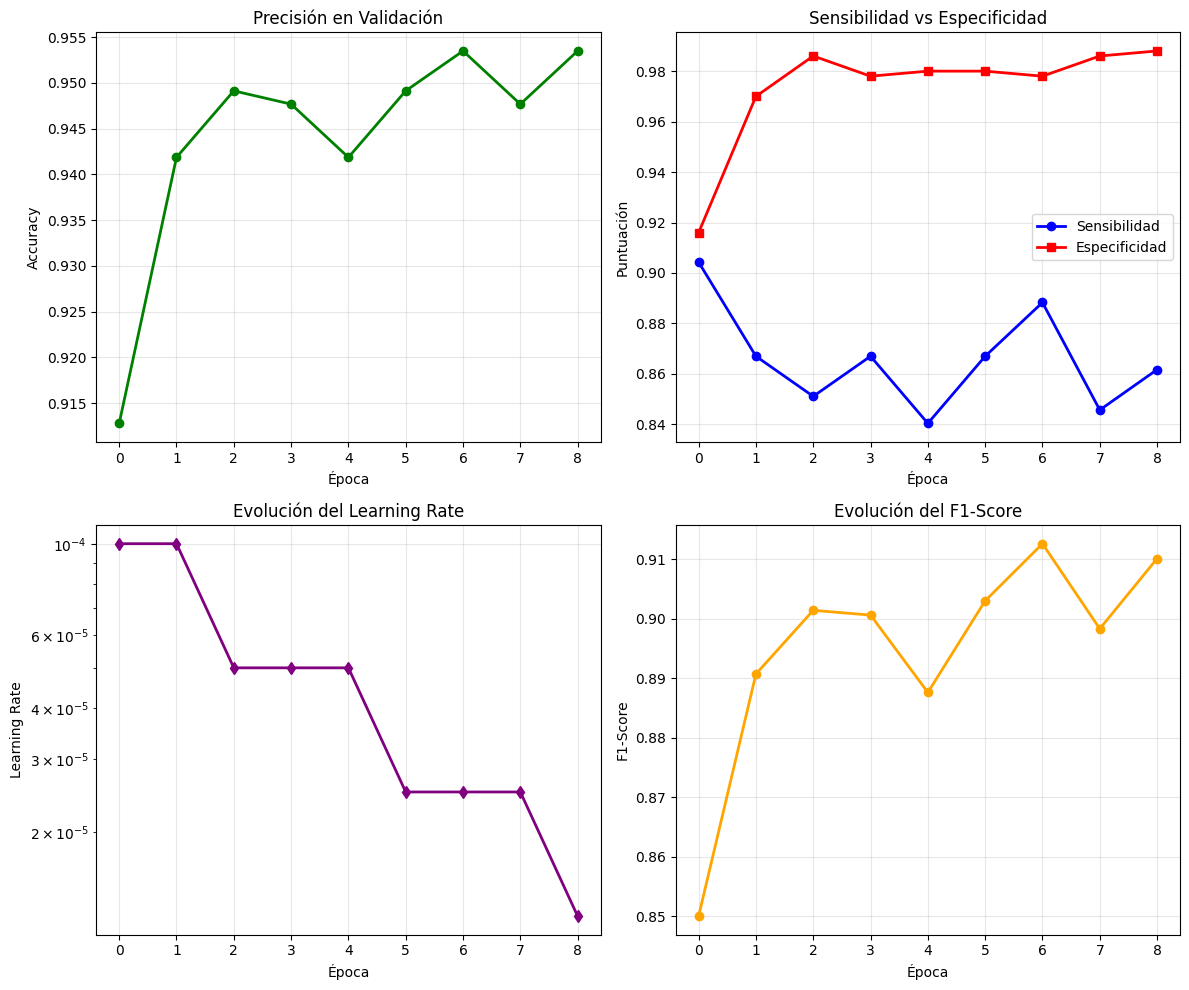

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy
axes[0, 0].plot(val_accuracies, 'g-', linewidth=2, marker='o')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Precisión en Validación')
axes[0, 0].grid(True, alpha=0.3)

# Sensibilidad y Especificidad (necesitas guardar estos valores)
sens = [0.9043, 0.8670, 0.8511, 0.8670, 0.8404, 0.8670, 0.8883, 0.8457, 0.8617]
spec = [0.9160, 0.9700, 0.9860, 0.9780, 0.9800, 0.9800, 0.9780, 0.9860, 0.9880]

axes[0, 1].plot(sens, 'b-', linewidth=2, label='Sensibilidad', marker='o')
axes[0, 1].plot(spec, 'r-', linewidth=2, label='Especificidad', marker='s')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Puntuación')
axes[0, 1].set_title('Sensibilidad vs Especificidad')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate (si guardaste los valores)
lrs = [1e-4, 1e-4, 5e-5, 5e-5, 5e-5, 2.5e-5, 2.5e-5, 2.5e-5, 1.25e-5]
axes[1, 0].plot(lrs[:len(train_losses)], 'purple', linewidth=2, marker='d')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Evolución del Learning Rate')
axes[1, 0].grid(True, alpha=0.3)

# F1-Score por época
f1_scores = [0.8500, 0.8907, 0.9014, 0.9006, 0.8876, 0.9030, 0.9126, 0.8983, 0.9101]
axes[1, 1].plot(f1_scores, 'orange', linewidth=2, marker='o')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('Evolución del F1-Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluación en test

In [35]:
# Cargar mejor modelo
checkpoint = torch.load('best_mobilenetv2.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss, test_acc, test_preds, test_labels, test_probs = validate_epoch(
    model, test_loader, criterion, DEVICE
)

print("RESULTADOS MOBILENET V2 - CONJUNTO DE TEST")

# Calcular métricas para test
test_precision = precision_score(test_labels, test_preds, zero_division=0)
test_recall = recall_score(test_labels, test_preds, zero_division=0)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)
test_auc = roc_auc_score(test_labels, test_probs)
cm_test = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm_test.ravel()
test_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss:.4f}")
print(f"  Accuracy:     {test_acc:.4f}")
print(f"  Precision:    {test_precision:.4f}")
print(f"  Recall (Sensibilidad): {test_recall:.4f}")
print(f"  Especificidad: {test_specificity:.4f}")
print(f"  F1-Score:     {test_f1:.4f}")
print(f"  AUC-ROC:      {test_auc:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test[0,0]}  FP: {cm_test[0,1]}")
print(f"    FN: {cm_test[1,0]}  TP: {cm_test[1,1]}")

# Mostrar porcentajes
print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity*100:.2f}%")
print(f"    Precisión (PPV): {test_precision*100:.2f}%")

RESULTADOS MOBILENET V2 - CONJUNTO DE TEST
  Loss:         0.2817
  Accuracy:     0.9533
  Precision:    0.9207
  Recall (Sensibilidad): 0.8882
  Especificidad: 0.9748
  F1-Score:     0.9042
  AUC-ROC:      0.9738

Matriz de confusión:
    TN: 502  FP: 13
    FN: 19  TP: 151

Porcentajes:
    Sensibilidad (TPR): 88.82%
    Especificidad (TNR): 97.48%
    Precisión (PPV): 92.07%


In [36]:
# CELDA MÁGICA - Guarda todo automáticamente
import json
import pandas as pd

# Resultados de MobileNetV2
mobilenet_results = {
    'model': 'MobileNetV2',
    'accuracy': test_acc,
    'precision': test_precision,
    'recall': test_recall,
    'specificity': test_specificity,
    'f1_score': test_f1,
    'auc_roc': test_auc,
    'tn': int(cm_test[0,0]),
    'fp': int(cm_test[0,1]),
    'fn': int(cm_test[1,0]),
    'tp': int(cm_test[1,1])
}

# Guardar como DataFrame
df_results = pd.DataFrame([mobilenet_results])
df_results.to_csv('MobileNetV2_results.csv', index=False)

# También guardar como JSON
with open('MobileNetV2_results.json', 'w') as f:
    json.dump(mobilenet_results, f, indent=4)

print("Resultados de MobileNetV2 guardados automáticamente!")
print("Archivos creados: MobileNetV2_results.csv y MobileNetV2_results.json")

Resultados de MobileNetV2 guardados automáticamente!
Archivos creados: MobileNetV2_results.csv y MobileNetV2_results.json


# DENSENET121

In [50]:
# Limpiar memoria antes de entrenar nuevo modelo
torch.cuda.empty_cache()
import gc
gc.collect()

# DENSENET121
class DenseNet121Classifier(nn.Module):
    def __init__(self):
        super(DenseNet121Classifier, self).__init__()
        self.backbone = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

# Crear modelo
model_densenet = DenseNet121Classifier().to(DEVICE)

print("Arquitectura DenseNet121:")
print(f"  Total parameters: {sum(p.numel() for p in model_densenet.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_densenet.parameters() if p.requires_grad):,}")

# Probar forward pass
test_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = model_densenet(test_input)
print(f"\nTest forward: input shape {test_input.shape} -> output shape {test_output.shape}")

# Calcular pos_weight (mismo que antes)
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

print(f"\nBalance de clases:")
print(f"  Negativos (0): {num_neg}")
print(f"  Positivos (1): {num_pos}")
print(f"  pos_weight: {pos_weight_value:.4f}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

# Optimizador (learning rate más bajo para modelo más grande)
optimizer_densenet = torch.optim.Adam(model_densenet.parameters(), lr=LEARNING_RATE)
scheduler_densenet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_densenet, mode='min', factor=0.5, patience=3
)

print(f"\nConfiguración:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 151MB/s]


Arquitectura DenseNet121:
  Total parameters: 6,954,881
  Trainable parameters: 6,954,881

Test forward: input shape torch.Size([2, 3, 224, 224]) -> output shape torch.Size([2])

Balance de clases:
  Negativos (0): 2445
  Positivos (1): 862
  pos_weight: 2.8364

Configuración:
  Device: cuda
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 20


## Entrenamiento

In [51]:
train_losses_dense = []
val_losses_dense = []
val_accuracies_dense = []
best_val_loss_dense = float('inf')
patience_counter_dense = 0

for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss, train_acc = train_epoch(model_densenet, train_loader, criterion, optimizer_densenet, DEVICE)

    # Validar
    val_loss, val_acc, preds, labels, probs = validate_epoch(model_densenet, val_loader, criterion, DEVICE)

    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar historial
    train_losses_dense.append(train_loss)
    val_losses_dense.append(val_loss)
    val_accuracies_dense.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    # Learning rate scheduling
    scheduler_densenet.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss_dense:
        best_val_loss_dense = val_loss
        patience_counter_dense = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_densenet.state_dict(),
            'optimizer_state_dict': optimizer_densenet.state_dict(),
            'val_loss': best_val_loss_dense,
        }, 'best_densenet121.pth')
        print(f"Nuevo mejor modelo guardado (loss: {best_val_loss_dense:.4f})")
    else:
        patience_counter_dense += 1
        if patience_counter_dense >= 7:
            print(f"Early stopping en epoch {epoch+1}")
            break

print(f"\nMejor modelo DenseNet121 con val_loss: {best_val_loss_dense:.4f}")


Epoch 1/20
  Train Loss: 0.5556 | Train Acc: 0.8183
  Val Loss:   0.3081 | Val Acc:   0.9390
  Precision: 0.8802 | Sensibilidad: 0.8989 | Especificidad: 0.9540 | F1: 0.8895
Nuevo mejor modelo guardado (loss: 0.3081)

Epoch 2/20
  Train Loss: 0.1722 | Train Acc: 0.9610
  Val Loss:   0.2472 | Val Acc:   0.9564
  Precision: 0.8950 | Sensibilidad: 0.9521 | Especificidad: 0.9580 | F1: 0.9227
Nuevo mejor modelo guardado (loss: 0.2472)

Epoch 3/20
  Train Loss: 0.0573 | Train Acc: 0.9918
  Val Loss:   0.2660 | Val Acc:   0.9564
  Precision: 0.9202 | Sensibilidad: 0.9202 | Especificidad: 0.9700 | F1: 0.9202

Epoch 4/20
  Train Loss: 0.0204 | Train Acc: 0.9982
  Val Loss:   0.3112 | Val Acc:   0.9637
  Precision: 0.9503 | Sensibilidad: 0.9149 | Especificidad: 0.9820 | F1: 0.9322

Epoch 5/20
  Train Loss: 0.0298 | Train Acc: 0.9933
  Val Loss:   0.2763 | Val Acc:   0.9462
  Precision: 0.8756 | Sensibilidad: 0.9362 | Especificidad: 0.9500 | F1: 0.9049

Epoch 6/20
  Train Loss: 0.0477 | Train Acc

## Visualizacion de resultados

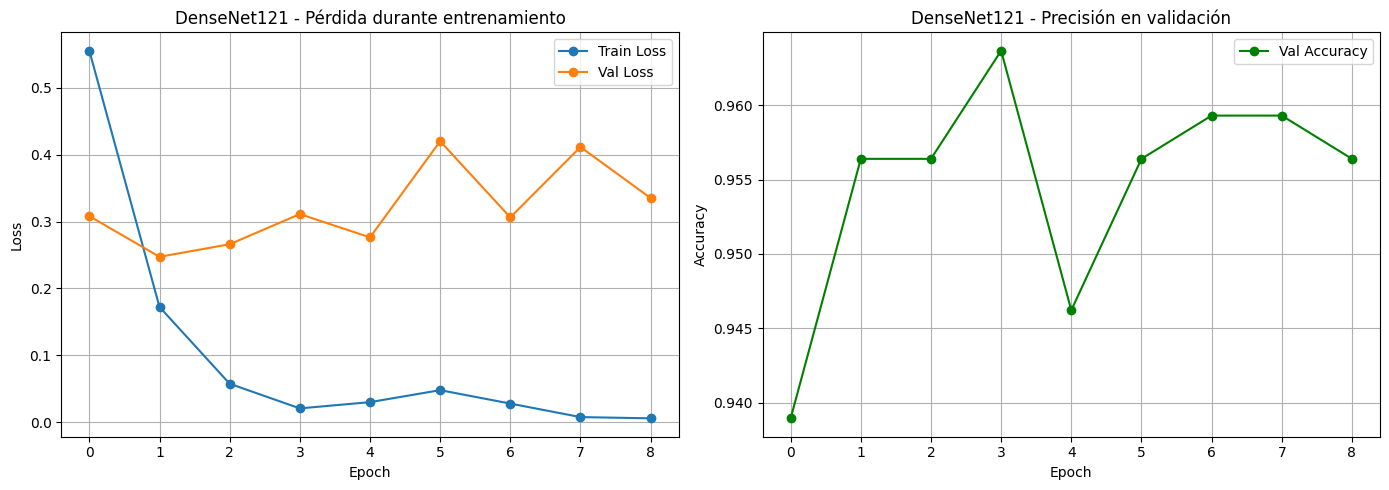

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(train_losses_dense, label='Train Loss', marker='o')
axes[0].plot(val_losses_dense, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('DenseNet121 - Pérdida durante entrenamiento')
axes[0].legend()
axes[0].grid(True)

# Gráfico de precisión
axes[1].plot(val_accuracies_dense, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('DenseNet121 - Precisión en validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluación en test

In [53]:
# Cargar mejor modelo
checkpoint = torch.load('best_densenet121.pth')
model_densenet.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_dense, test_acc_dense, test_preds_dense, test_labels_dense, test_probs_dense = validate_epoch(
    model_densenet, test_loader, criterion, DEVICE
)

# Calcular métricas para test
test_precision_dense = precision_score(test_labels_dense, test_preds_dense, zero_division=0)
test_recall_dense = recall_score(test_labels_dense, test_preds_dense, zero_division=0)
test_f1_dense = f1_score(test_labels_dense, test_preds_dense, zero_division=0)
test_auc_dense = roc_auc_score(test_labels_dense, test_probs_dense)
cm_test_dense = confusion_matrix(test_labels_dense, test_preds_dense)
tn, fp, fn, tp = cm_test_dense.ravel()
test_specificity_dense = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss_dense:.4f}")
print(f"  Accuracy:     {test_acc_dense:.4f}")
print(f"  Precision:    {test_precision_dense:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_dense:.4f}")
print(f"  Especificidad: {test_specificity_dense:.4f}")
print(f"  F1-Score:     {test_f1_dense:.4f}")
print(f"  AUC-ROC:      {test_auc_dense:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_dense[0,0]}  FP: {cm_test_dense[0,1]}")
print(f"    FN: {cm_test_dense[1,0]}  TP: {cm_test_dense[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_dense*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_dense*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_dense*100:.2f}%")

  Loss:         0.2801
  Accuracy:     0.9416
  Precision:    0.8652
  Recall (Sensibilidad): 0.9059
  Especificidad: 0.9534
  F1-Score:     0.8851
  AUC-ROC:      0.9745

Matriz de confusión:
    TN: 491  FP: 24
    FN: 16  TP: 154

Porcentajes:
    Sensibilidad (TPR): 90.59%
    Especificidad (TNR): 95.34%
    Precisión (PPV): 86.52%


In [54]:
import json
import pandas as pd

densenet_results = {
    'model': 'DenseNet121',
    'accuracy': test_acc_dense,
    'precision': test_precision_dense,
    'recall': test_recall_dense,
    'specificity': test_specificity_dense,
    'f1_score': test_f1_dense,
    'auc_roc': test_auc_dense,
    'tn': int(cm_test_dense[0,0]),
    'fp': int(cm_test_dense[0,1]),
    'fn': int(cm_test_dense[1,0]),
    'tp': int(cm_test_dense[1,1])
}

pd.DataFrame([densenet_results]).to_csv(
    'DenseNet121_results.csv',
    index=False
)

with open('DenseNet121_results.json', 'w') as f:
    json.dump(densenet_results, f, indent=4)

print("Resultados de DenseNet121 guardados.")

Resultados de DenseNet121 guardados.


# EFFICIENTNET-B0

In [57]:
from torchvision.models import EfficientNet_B0_Weights

# Limpiar memoria antes de entrenar nuevo modelo
torch.cuda.empty_cache()
import gc
gc.collect()

# EFFICIENTNET-B0
class EfficientNetB0Classifier(nn.Module):
    def __init__(self):
        super(EfficientNetB0Classifier, self).__init__()
        self.backbone = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

# Crear modelo
model_efficientnet = EfficientNetB0Classifier().to(DEVICE)

print("Arquitectura EfficientNet-B0:")
print(f"  Total parameters: {sum(p.numel() for p in model_efficientnet.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model_efficientnet.parameters() if p.requires_grad):,}")

# Probar forward pass
test_input = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = model_efficientnet(test_input)
print(f"\nTest forward: input shape {test_input.shape} -> output shape {test_output.shape}")

# Calcular pos_weight (mismo que antes)
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

print(f"\nBalance de clases:")
print(f"  Negativos (0): {num_neg}")
print(f"  Positivos (1): {num_pos}")
print(f"  pos_weight: {pos_weight_value:.4f}")

# Función de pérdida
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

# Optimizador
optimizer_efficientnet = torch.optim.Adam(model_efficientnet.parameters(), lr=LEARNING_RATE)
scheduler_efficientnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_efficientnet, mode='min', factor=0.5, patience=3
)

print(f"\nConfiguración:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 113MB/s] 


Arquitectura EfficientNet-B0:
  Total parameters: 4,008,829
  Trainable parameters: 4,008,829

Test forward: input shape torch.Size([2, 3, 224, 224]) -> output shape torch.Size([2])

Balance de clases:
  Negativos (0): 2445
  Positivos (1): 862
  pos_weight: 2.8364

Configuración:
  Device: cuda
  Batch size: 32
  Learning rate: 0.0001
  Epochs: 20


## Entrenamiento

In [58]:
train_losses_efficient = []
val_losses_efficient = []
val_accuracies_efficient = []
best_val_loss_efficient = float('inf')
patience_counter_efficient = 0

for epoch in range(NUM_EPOCHS):
    # Entrenar
    train_loss, train_acc = train_epoch(model_efficientnet, train_loader, criterion, optimizer_efficientnet, DEVICE)

    # Validar
    val_loss, val_acc, preds, labels, probs = validate_epoch(model_efficientnet, val_loader, criterion, DEVICE)

    # Métricas adicionales
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Guardar historial
    train_losses_efficient.append(train_loss)
    val_losses_efficient.append(val_loss)
    val_accuracies_efficient.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    # Learning rate scheduling
    scheduler_efficientnet.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss_efficient:
        best_val_loss_efficient = val_loss
        patience_counter_efficient = 0
        # Guardar mejor modelo
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_efficientnet.state_dict(),
            'optimizer_state_dict': optimizer_efficientnet.state_dict(),
            'val_loss': best_val_loss_efficient,
        }, 'best_efficientnetb0.pth')
        print(f"Nuevo mejor modelo guardado (loss: {best_val_loss_efficient:.4f})")
    else:
        patience_counter_efficient += 1
        if patience_counter_efficient >= 7:
            print(f"Early stopping en epoch {epoch+1}")
            break

print(f"\nMejor modelo EfficientNet-B0 con val_loss: {best_val_loss_efficient:.4f}")


Epoch 1/20
  Train Loss: 0.7748 | Train Acc: 0.7182
  Val Loss:   0.4403 | Val Acc:   0.8692
  Precision: 0.7008 | Sensibilidad: 0.9096 | Especificidad: 0.8540 | F1: 0.7917
Nuevo mejor modelo guardado (loss: 0.4403)

Epoch 2/20
  Train Loss: 0.3378 | Train Acc: 0.9226
  Val Loss:   0.2746 | Val Acc:   0.9346
  Precision: 0.8454 | Sensibilidad: 0.9309 | Especificidad: 0.9360 | F1: 0.8861
Nuevo mejor modelo guardado (loss: 0.2746)

Epoch 3/20
  Train Loss: 0.1520 | Train Acc: 0.9713
  Val Loss:   0.2348 | Val Acc:   0.9448
  Precision: 0.8676 | Sensibilidad: 0.9415 | Especificidad: 0.9460 | F1: 0.9031
Nuevo mejor modelo guardado (loss: 0.2348)

Epoch 4/20
  Train Loss: 0.0776 | Train Acc: 0.9879
  Val Loss:   0.3065 | Val Acc:   0.9491
  Precision: 0.9371 | Sensibilidad: 0.8723 | Especificidad: 0.9780 | F1: 0.9036

Epoch 5/20
  Train Loss: 0.0515 | Train Acc: 0.9915
  Val Loss:   0.2718 | Val Acc:   0.9549
  Precision: 0.9198 | Sensibilidad: 0.9149 | Especificidad: 0.9700 | F1: 0.9173



## Visualización de resultados

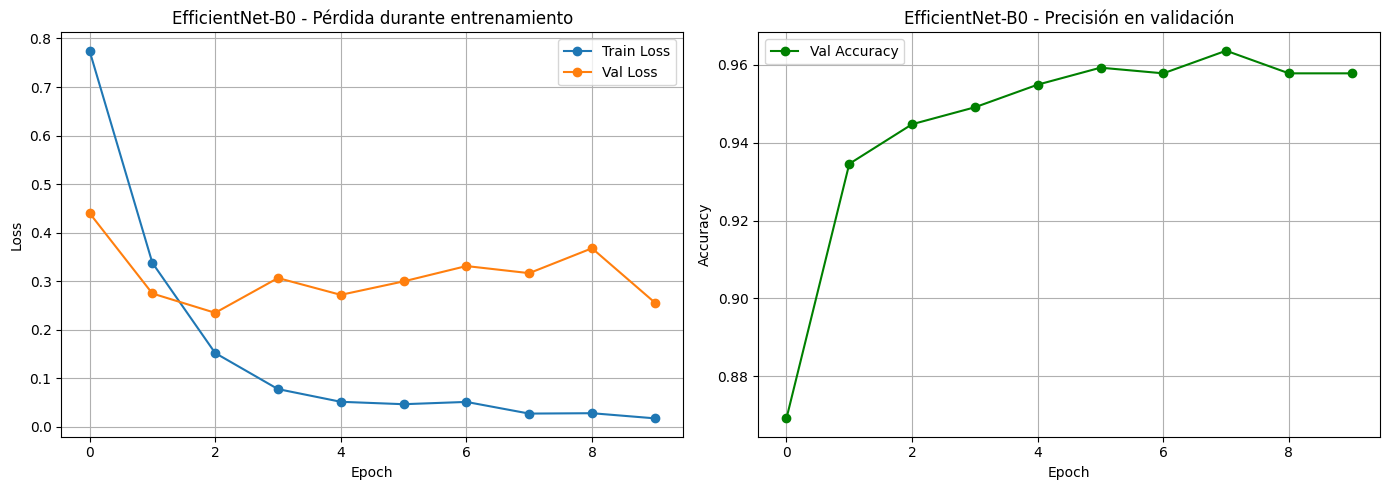

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(train_losses_efficient, label='Train Loss', marker='o')
axes[0].plot(val_losses_efficient, label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('EfficientNet-B0 - Pérdida durante entrenamiento')
axes[0].legend()
axes[0].grid(True)

# Gráfico de precisión
axes[1].plot(val_accuracies_efficient, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('EfficientNet-B0 - Precisión en validación')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluación en test

In [60]:
# Cargar mejor modelo
checkpoint = torch.load('best_efficientnetb0.pth')
model_efficientnet.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_efficient, test_acc_efficient, test_preds_efficient, test_labels_efficient, test_probs_efficient = validate_epoch(
    model_efficientnet, test_loader, criterion, DEVICE
)

# Calcular métricas para test
test_precision_efficient = precision_score(test_labels_efficient, test_preds_efficient, zero_division=0)
test_recall_efficient = recall_score(test_labels_efficient, test_preds_efficient, zero_division=0)
test_f1_efficient = f1_score(test_labels_efficient, test_preds_efficient, zero_division=0)
test_auc_efficient = roc_auc_score(test_labels_efficient, test_probs_efficient)
cm_test_efficient = confusion_matrix(test_labels_efficient, test_preds_efficient)
tn, fp, fn, tp = cm_test_efficient.ravel()
test_specificity_efficient = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"  Loss:         {test_loss_efficient:.4f}")
print(f"  Accuracy:     {test_acc_efficient:.4f}")
print(f"  Precision:    {test_precision_efficient:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_efficient:.4f}")
print(f"  Especificidad: {test_specificity_efficient:.4f}")
print(f"  F1-Score:     {test_f1_efficient:.4f}")
print(f"  AUC-ROC:      {test_auc_efficient:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_efficient[0,0]}  FP: {cm_test_efficient[0,1]}")
print(f"    FN: {cm_test_efficient[1,0]}  TP: {cm_test_efficient[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_efficient*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_efficient*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_efficient*100:.2f}%")

  Loss:         0.2595
  Accuracy:     0.9328
  Precision:    0.8100
  Recall (Sensibilidad): 0.9529
  Especificidad: 0.9262
  F1-Score:     0.8757
  AUC-ROC:      0.9844

Matriz de confusión:
    TN: 477  FP: 38
    FN: 8  TP: 162

Porcentajes:
    Sensibilidad (TPR): 95.29%
    Especificidad (TNR): 92.62%
    Precisión (PPV): 81.00%


In [61]:
import json
import pandas as pd

efficientnet_results = {
    'model': 'EfficientNet-B0',
    'accuracy': test_acc_efficient,
    'precision': test_precision_efficient,
    'recall': test_recall_efficient,
    'specificity': test_specificity_efficient,
    'f1_score': test_f1_efficient,
    'auc_roc': test_auc_efficient,
    'tn': int(cm_test_efficient[0,0]),
    'fp': int(cm_test_efficient[0,1]),
    'fn': int(cm_test_efficient[1,0]),
    'tp': int(cm_test_efficient[1,1])
}

# Guardar como CSV
pd.DataFrame([efficientnet_results]).to_csv('EfficientNetB0_results.csv', index=False)

# Guardar como JSON
with open('EfficientNetB0_results.json', 'w') as f:
    json.dump(efficientnet_results, f, indent=4)

print("\nResultados de EfficientNet-B0 guardados")



Resultados de EfficientNet-B0 guardados


# FALTA

# ResNet18 + LSTM

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import numpy as np
import cv2
import os
import gc

class ResNet18LSTM(nn.Module):
    def __init__(self, num_classes=1, lstm_hidden=256, num_layers=2, dropout=0.2):
        super(ResNet18LSTM, self).__init__()

        # ResNet18 pre-entrenado (sin el clasificador final)
        self.resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # Eliminar clasificador, solo características

        # LSTM para procesar secuencias
        self.lstm = nn.LSTM(
            input_size=in_features,  # 512 features de ResNet
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        # Capa final de clasificación
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size, seq_len, C, H, W = x.shape
        x = x.view(batch_size * seq_len, C, H, W)
        features = self.resnet(x)
        features = features.view(batch_size, seq_len, -1)
        lstm_out, (hidden, cell) = self.lstm(features)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output.squeeze(1)

## Modificación del dataset para soportar secuencias

In [ ]:
class LungCancerSequenceDataset(Dataset):
    def __init__(self, dataframe, patch_size=(64, 64, 64), target_size=(224, 224), seq_len=16):
        self.df = dataframe.reset_index(drop=True)
        self.patch_size = patch_size
        self.target_size = target_size
        self.seq_len = seq_len

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]['path']
        label = self.df.iloc[idx]['label']

        # Cargar patch 3D
        if not os.path.exists(path):
            patch = np.zeros((64, 64, 64), dtype=np.float32)
        else:
            patch = np.load(path)  # shape: (64, 64, 64)

        z_center = patch.shape[0] // 2

        #Calcular índices de slices
        total_slices = patch.shape[0]

        # Crear índices espaciados uniformemente alrededor del centro
        half_seq = self.seq_len // 2
        start_idx = max(0, z_center - half_seq)
        end_idx = min(total_slices, z_center + half_seq)

        # Seleccionar índices
        indices = np.linspace(start_idx, end_idx - 1, self.seq_len).astype(int)

        # Extraer slices
        slices = []
        for z in indices:
            axial_slice = patch[z, :, :]
            axial = (axial_slice * 255).astype(np.uint8)
            axial_resized = cv2.resize(axial, self.target_size, interpolation=cv2.INTER_LINEAR)
            axial_norm = axial_resized / 255.0
            slices.append(axial_norm)

        # Convertir a secuencia con 3 canales
        sequence = []
        for slice_img in slices:
            slice_tensor = torch.from_numpy(slice_img).float().unsqueeze(0)
            slice_tensor = slice_tensor.repeat(3, 1, 1)
            slice_tensor = self.normalize(slice_tensor)
            sequence.append(slice_tensor)

        sequence = torch.stack(sequence, dim=0)  # (seq_len, 3, H, W)
        label = torch.tensor(float(label), dtype=torch.float32)

        return sequence, label

## Entrenamiento

In [ ]:
# Limpiar memoria
torch.cuda.empty_cache()
gc.collect()

# Configuración
SEQ_LEN = 16
BATCH_SIZE = 16  # Reducir batch size para LSTM (usa más memoria)

# Crear datasets
train_sequence_dataset = LungCancerSequenceDataset(train_df, seq_len=SEQ_LEN)
val_sequence_dataset = LungCancerSequenceDataset(val_df, seq_len=SEQ_LEN)
test_sequence_dataset = LungCancerSequenceDataset(test_df, seq_len=SEQ_LEN)

print(f"Datasets de secuencias creados")
print(f"  Train: {len(train_sequence_dataset)} muestras")
print(f"  Val: {len(val_sequence_dataset)} muestras")
print(f"  Test: {len(test_sequence_dataset)} muestras")

# Verificar forma
sample_seq, sample_label = train_sequence_dataset[0]
print(f"  Secuencia ejemplo: {sample_seq.shape}")  # (SEQ_LEN, 3, 224, 224)

# DataLoaders (batch_size reducido)
train_loader_seq = DataLoader(
    train_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_seq = DataLoader(
    val_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_seq = DataLoader(
    test_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Crear modelo
model_resnet_lstm = ResNet18LSTM(
    num_classes=1,
    lstm_hidden=256,
    num_layers=2,
    dropout=0.2
).to(DEVICE)

print(f"\nArquitectura ResNet18+LSTM:")
print(f"  Total parameters: {sum(p.numel() for p in model_resnet_lstm.parameters()):,}")

# Test forward
test_input = torch.randn(2, SEQ_LEN, 3, 224, 224).to(DEVICE)
test_output = model_resnet_lstm(test_input)
print(f"  Test forward: {test_input.shape} -> {test_output.shape}")

# Función de pérdida
train_labels = [train_df.iloc[i]['label'] for i in range(len(train_df))]
num_neg = train_labels.count(0)
num_pos = train_labels.count(1)
pos_weight_value = num_neg / num_pos

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value]).to(DEVICE)
)

optimizer_lstm = torch.optim.Adam(model_resnet_lstm.parameters(), lr=LEARNING_RATE)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lstm, mode='min', factor=0.5, patience=3
)

## Funciones

In [ ]:
def train_epoch_seq(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * sequences.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader.dataset), correct / total


def validate_epoch_seq(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * sequences.size(0)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return (running_loss / len(loader.dataset),
            correct / total,
            all_preds, all_labels, all_probs)

## Bucle de entrenamiento

In [ ]:
train_losses_lstm = []
val_losses_lstm = []
val_accuracies_lstm = []
best_val_loss_lstm = float('inf')
patience_counter_lstm = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch_seq(model_resnet_lstm, train_loader_seq,
                                             criterion, optimizer_lstm, DEVICE)

    val_loss, val_acc, preds, labels, probs = validate_epoch_seq(
        model_resnet_lstm, val_loader_seq, criterion, DEVICE
    )

    # Métricas
    from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    train_losses_lstm.append(train_loss)
    val_losses_lstm.append(val_loss)
    val_accuracies_lstm.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  Precision: {precision:.4f} | Sensibilidad: {recall:.4f} | Especificidad: {specificity:.4f} | F1: {f1:.4f}")

    scheduler_lstm.step(val_loss)

    if val_loss < best_val_loss_lstm:
        best_val_loss_lstm = val_loss
        patience_counter_lstm = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_resnet_lstm.state_dict(),
            'optimizer_state_dict': optimizer_lstm.state_dict(),
            'val_loss': best_val_loss_lstm,
        }, 'best_resnet18_lstm.pth')
        print(f"Nuevo mejor modelo guardado (loss: {best_val_loss_lstm:.4f})")
    else:
        patience_counter_lstm += 1
        if patience_counter_lstm >= 7:
            print(f"Early stopping en epoch {epoch+1}")
            break

print(f"\nMejor modelo ResNet18+LSTM con val_loss: {best_val_loss_lstm:.4f}")


## Evaluación en test

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load('best_resnet18_lstm.pth')
model_resnet_lstm.load_state_dict(checkpoint['model_state_dict'])

# Evaluar en test
test_loss_lstm, test_acc_lstm, test_preds_lstm, test_labels_lstm, test_probs_lstm = validate_epoch_seq(
    model_resnet_lstm, test_loader_seq, criterion, DEVICE
)

# Calcular métricas
test_precision_lstm = precision_score(test_labels_lstm, test_preds_lstm, zero_division=0)
test_recall_lstm = recall_score(test_labels_lstm, test_preds_lstm, zero_division=0)
test_f1_lstm = f1_score(test_labels_lstm, test_preds_lstm, zero_division=0)
test_auc_lstm = roc_auc_score(test_labels_lstm, test_probs_lstm)
cm_test_lstm = confusion_matrix(test_labels_lstm, test_preds_lstm)
tn, fp, fn, tp = cm_test_lstm.ravel()
test_specificity_lstm = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*60)
print("RESULTADOS RESNET18+LSTM - CONJUNTO DE TEST")
print("="*60)
print(f"  Loss:         {test_loss_lstm:.4f}")
print(f"  Accuracy:     {test_acc_lstm:.4f}")
print(f"  Precision:    {test_precision_lstm:.4f}")
print(f"  Recall (Sensibilidad): {test_recall_lstm:.4f}")
print(f"  Especificidad: {test_specificity_lstm:.4f}")
print(f"  F1-Score:     {test_f1_lstm:.4f}")
print(f"  AUC-ROC:      {test_auc_lstm:.4f}")

print(f"\nMatriz de confusión:")
print(f"    TN: {cm_test_lstm[0,0]}  FP: {cm_test_lstm[0,1]}")
print(f"    FN: {cm_test_lstm[1,0]}  TP: {cm_test_lstm[1,1]}")

print(f"\nPorcentajes:")
print(f"    Sensibilidad (TPR): {test_recall_lstm*100:.2f}%")
print(f"    Especificidad (TNR): {test_specificity_lstm*100:.2f}%")
print(f"    Precisión (PPV): {test_precision_lstm*100:.2f}%")

# Gráficos de los modelos

In [55]:
# ============================================
# GENERAR TODOS LOS GRÁFICOS PARA DENSENET121
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import math

# Crear directorio para los gráficos
os.makedirs('plots/DenseNet121', exist_ok=True)

# ============================================
# GRÁFICO 1: Curvas de Pérdida (Loss)
# ============================================
print("Generando gráfico 1: Curvas de pérdida...")

fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, len(train_losses_dense) + 1)

ax.plot(epochs, train_losses_dense, 'o-', color='#2ecc71', linewidth=2,
        markersize=6, label='Train Loss', markeredgecolor='black', markeredgewidth=0.5)
ax.plot(epochs, val_losses_dense, 's-', color='#e74c3c', linewidth=2,
        markersize=6, label='Validation Loss', markeredgecolor='black', markeredgewidth=0.5)

# Rellenar área entre curvas
ax.fill_between(epochs, train_losses_dense, val_losses_dense, alpha=0.2, color='gray')

# Marcar mejor época
best_epoch = val_losses_dense.index(min(val_losses_dense)) + 1
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.text(best_epoch, max(train_losses_dense), f'Best epoch\n{best_epoch}',
        ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (Binary Cross Entropy)', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir anotación con mejor pérdida
ax.text(0.02, 0.98, f'Best Val Loss: {min(val_losses_dense):.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/DenseNet121/1_loss_curves.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 2: Accuracy en Validación
# ============================================
print("Generando gráfico 2: Accuracy en validación...")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs, val_accuracies_dense, 'o-', color='#3498db', linewidth=2,
        markersize=6, label='Validation Accuracy', markeredgecolor='black', markeredgewidth=0.5)
ax.fill_between(epochs, val_accuracies_dense, alpha=0.2, color='#3498db')

# Marcar mejor accuracy
best_acc = max(val_accuracies_dense)
best_acc_epoch = val_accuracies_dense.index(best_acc) + 1
ax.axhline(y=best_acc, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])

ax.text(0.02, 0.98, f'Best Accuracy: {best_acc:.4f} (Epoch {best_acc_epoch})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/DenseNet121/2_validation_accuracy.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 3: Curva ROC
# ============================================
print("Generando gráfico 3: Curva ROC...")

fpr, tpr, _ = roc_curve(test_labels_dense, test_probs_dense)
roc_auc = test_auc_dense

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'DenseNet121 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir punto del umbral 0.5
tpr_50 = test_recall_dense
fpr_50 = 1 - test_specificity_dense
ax.plot(fpr_50, tpr_50, 'ro', markersize=10, label=f'Threshold 0.5 (TPR={tpr_50:.3f}, FPR={fpr_50:.3f})')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('plots/DenseNet121/3_roc_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 4: Matriz de Confusión
# ============================================
print("Generando gráfico 4: Matriz de confusión...")

cm = confusion_matrix(test_labels_dense, test_preds_dense)
cm_percent = cm / cm.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (Healthy)', 'Positive (Cancer)'],
            yticklabels=['Negative (Healthy)', 'Positive (Cancer)'],
            ax=ax, cbar_kws={'label': 'Count'})

# Añadir porcentajes en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.7, f'\n({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=10, color='black')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/DenseNet121/4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 5: Barras de Métricas
# ============================================
print("Generando gráfico 5: Barras de métricas...")

metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC-ROC']
values = [test_acc_dense, test_recall_dense, test_specificity_dense,
          test_precision_dense, test_f1_dense, test_auc_dense]
colors_metrics = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(metrics, values, color=colors_metrics, edgecolor='black', linewidth=1.5)

# Umbral clínico
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Clinical Threshold (85%)')

# Añadir valores en las barras
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Performance Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('plots/DenseNet121/5_metrics_bars.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 6: Distribución de Probabilidades
# ============================================
print("Generando gráfico 6: Distribución de probabilidades...")

pos_probs = [test_probs_dense[i] for i in range(len(test_labels_dense)) if test_labels_dense[i] == 1]
neg_probs = [test_probs_dense[i] for i in range(len(test_labels_dense)) if test_labels_dense[i] == 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(neg_probs, bins=30, alpha=0.6, color='green', label=f'Healthy (n={len(neg_probs)})',
        density=True, edgecolor='black')
ax.hist(pos_probs, bins=30, alpha=0.6, color='red', label=f'Cancer (n={len(pos_probs)})',
        density=True, edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')

# Añadir región de errores
ax.axvspan(0.5, 1, alpha=0.1, color='red', label='False Positives Region (FP)')
ax.axvspan(0, 0.5, alpha=0.1, color='blue', label='False Negatives Region (FN)')

ax.set_xlabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Probability Distribution by Class', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/DenseNet121/6_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 7: Curva Precisión-Recall
# ============================================
print("Generando gráfico 7: Curva Precisión-Recall...")

precision_curve, recall_curve, _ = precision_recall_curve(test_labels_dense, test_probs_dense)
avg_precision = average_precision_score(test_labels_dense, test_probs_dense)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_curve, precision_curve, 'b-', linewidth=3, label=f'DenseNet121 (AP = {avg_precision:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.2, color='blue')

# Punto del modelo
ax.plot(test_recall_dense, test_precision_dense, 'ro', markersize=10, label='Current Model')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/DenseNet121/7_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 8: Boxplot de Predicciones
# ============================================
print("Generando gráfico 8: Boxplot...")

fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [neg_probs, pos_probs]
bp = ax.boxplot(data_to_plot, labels=['Healthy\n(Negative)', 'Cancer\n(Positive)'],
                patch_artist=True, showmeans=True, meanline=True)

# Colores
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
bp['medians'][0].set_color('black')
bp['medians'][1].set_color('black')
bp['medians'][0].set_linewidth(2)
bp['medians'][1].set_linewidth(2)
bp['means'][0].set_marker('D')
bp['means'][1].set_marker('D')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax.set_ylabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Prediction Distribution by True Class', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('plots/DenseNet121/8_boxplot.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 9: Análisis de Errores
# ============================================
print("Generando gráfico 9: Análisis de errores...")

errors_df = pd.DataFrame({
    'True Label': test_labels_dense,
    'Predicted': test_preds_dense,
    'Probability': test_probs_dense
})
errors_df['Error Type'] = errors_df.apply(
    lambda x: 'False Positive (FP)' if x['True Label']==0 and x['Predicted']==1 else
              ('False Negative (FN)' if x['True Label']==1 and x['Predicted']==0 else 'Correct'),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))

fp_probs = errors_df[errors_df['Error Type']=='False Positive (FP)']['Probability']
fn_probs = errors_df[errors_df['Error Type']=='False Negative (FN)']['Probability']

ax.hist(fp_probs, bins=20, alpha=0.7, color='orange', label=f'False Positives (n={len(fp_probs)})', edgecolor='black')
ax.hist(fn_probs, bins=20, alpha=0.7, color='red', label=f'False Negatives (n={len(fn_probs)})', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')

ax.set_xlabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Error Analysis (FP vs FN)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/DenseNet121/9_error_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 10: Radar Chart
# ============================================
print("Generando gráfico 10: Radar chart...")

categories = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
values_radar = [test_acc_dense, test_recall_dense, test_specificity_dense,
                test_precision_dense, test_f1_dense]

# Cerrar el polígono
values_radar += values_radar[:1]
angles = [n / float(len(categories)) * 2 * math.pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles, values_radar, 'o-', linewidth=2, color='#3498db', label='DenseNet121')
ax.fill(angles, values_radar, alpha=0.25, color='#3498db')

# Área de referencia (clasificador ideal)
ideal = [1] * len(categories)
ideal += ideal[:1]
ax.plot(angles, ideal, 'r--', linewidth=1, alpha=0.5, label='Ideal (1.0)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('DenseNet121 - Metrics Radar Chart', size=14, pad=20, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig('plots/DenseNet121/10_radar_chart.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO ADICIONAL: Curvas de pérdida combinadas (Training vs Validation)
# ============================================
print("Generando gráfico adicional: Pérdida combinada...")

fig, ax = plt.subplots(figsize=(10, 6))

# Rango de épocas entrenadas
epochs = range(1, len(train_losses_dense) + 1)

# Líneas con marcadores mejorados
ax.plot(epochs, train_losses_dense, 'o-', color='#2ecc71', linewidth=2,
        markersize=7, label='Training Loss', markeredgecolor='black', markeredgewidth=0.5)
ax.plot(epochs, val_losses_dense, 's-', color='#e74c3c', linewidth=2,
        markersize=7, label='Validation Loss', markeredgecolor='black', markeredgewidth=0.5)

# Mejor época
best_epoch_idx = val_losses_dense.index(min(val_losses_dense))
ax.axvline(x=best_epoch_idx + 1, color='purple', linestyle='--', linewidth=2,
           alpha=0.7, label=f'Best Model (Epoch {best_epoch_idx + 1})')

# Resaltar área de overfitting (si existe)
if len(train_losses_dense) > 5:
    overfit_start = len(train_losses_dense) // 2
    ax.axvspan(overfit_start, len(train_losses_dense), alpha=0.1, color='red',
               label='Potential Overfitting Region')

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('DenseNet121 - Training Dynamics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir texto con información del mejor modelo
ax.text(0.02, 0.98, f'Best Val Loss: {min(val_losses_dense):.4f}\nBest Train Loss: {min(train_losses_dense):.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/DenseNet121/11_combined_loss.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GENERAR REPORTE HTML
# ============================================
print("Generando reporte HTML...")

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>DenseNet121 - Results Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
        h1 {{ color: #2c3e50; text-align: center; }}
        h2 {{ color: #34495e; border-bottom: 2px solid #3498db; }}
        .metrics-table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        .metrics-table th, .metrics-table td {{ border: 1px solid #ddd; padding: 12px; text-align: center; }}
        .metrics-table th {{ background-color: #3498db; color: white; }}
        .metric-good {{ background-color: #d4edda; color: #155724; }}
        .metric-excellent {{ background-color: #c3e6cb; color: #155724; font-weight: bold; }}
        .container {{ max-width: 1200px; margin: auto; background: white; padding: 20px; border-radius: 10px; }}
        .plot-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(500px, 1fr)); gap: 20px; }}
        .plot-card {{ background: white; border: 1px solid #ddd; border-radius: 8px; padding: 15px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .plot-card img {{ width: 100%; height: auto; border-radius: 4px; }}
    </style>
</head>
<body>
    <div class="container">
        <h1> DenseNet121 - Performance Report</h1>

        <h2> Key Metrics Summary</h2>
        <table class="metrics-table">
            <tr><th>Metric</th><th>Value</th><th>Evaluation</th></tr>
            <tr><td>Accuracy</td><td class="{'metric-excellent' if test_acc_dense > 0.95 else 'metric-good'}">{test_acc_dense:.3f} ({test_acc_dense*100:.1f}%)</td><td>{'Excellent' if test_acc_dense > 0.95 else 'Good'}</td></tr>
            <tr><td>Sensitivity (Recall)</td><td class="{'metric-good' if test_recall_dense > 0.85 else ''}">{test_recall_dense:.3f} ({test_recall_dense*100:.1f}%)</td><td>{'Good' if test_recall_dense > 0.85 else 'Needs Improvement'}</td></tr>
            <tr><td>Specificity</td><td class="{'metric-excellent' if test_specificity_dense > 0.95 else 'metric-good'}">{test_specificity_dense:.3f} ({test_specificity_dense*100:.1f}%)</td><td>{'Excellent' if test_specificity_dense > 0.95 else 'Good'}</td></tr>
            <tr><td>Precision</td><td class="{'metric-good' if test_precision_dense > 0.90 else ''}">{test_precision_dense:.3f} ({test_precision_dense*100:.1f}%)</td><td>{'Good' if test_precision_dense > 0.90 else 'Needs Improvement'}</td></tr>
            <tr><td>F1-Score</td><td class="{'metric-good' if test_f1_dense > 0.90 else ''}">{test_f1_dense:.3f}</td><td>{'Good' if test_f1_dense > 0.90 else 'Needs Improvement'}</td></tr>
            <tr><td>AUC-ROC</td><td class="metric-excellent">{test_auc_dense:.3f}</td><td>Excellent</td></tr>
        </table>

        <h2>Confusion Matrix Details</h2>
        <table class="metrics-table">
            <tr><th></th><th>Predicted Negative</th><th>Predicted Positive</th></tr>
            <tr><th>True Negative</th><td>{cm[0,0]}</td><td>{cm[0,1]}</td></tr>
            <tr><th>True Positive</th><td>{cm[1,0]}</td><td>{cm[1,1]}</td></tr>
        </table>

        <h2>Performance Plots</h2>
        <div class="plot-grid">
            <div class="plot-card"><h3>Loss Curves</h3><img src="1_loss_curves.png" alt="Loss Curves"></div>
            <div class="plot-card"><h3>Validation Accuracy</h3><img src="2_validation_accuracy.png" alt="Accuracy"></div>
            <div class="plot-card"><h3>ROC Curve</h3><img src="3_roc_curve.png" alt="ROC"></div>
            <div class="plot-card"><h3>Confusion Matrix</h3><img src="4_confusion_matrix.png" alt="Confusion Matrix"></div>
            <div class="plot-card"><h3>Metrics Bars</h3><img src="5_metrics_bars.png" alt="Metrics"></div>
            <div class="plot-card"><h3>Probability Distribution</h3><img src="6_probability_distribution.png" alt="Distribution"></div>
        </div>

        <p style="text-align: center; margin-top: 40px; color: #7f8c8d;">
            Report generated automatically | DenseNet121 | Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
        </p>
    </div>
</body>
</html>
"""

with open('plots/DenseNet121/report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

# Mostrar resumen de archivos
import os
print("\nContenido de la carpeta:")
for file in os.listdir('plots/DenseNet121'):
    if file.endswith('.png') or file.endswith('.html'):
        print(f"   - {file}")

Generando gráfico 1: Curvas de pérdida...
Generando gráfico 2: Accuracy en validación...
Generando gráfico 3: Curva ROC...
Generando gráfico 4: Matriz de confusión...
Generando gráfico 5: Barras de métricas...
📈 Generando gráfico 6: Distribución de probabilidades...
Generando gráfico 7: Curva Precisión-Recall...
Generando gráfico 8: Boxplot...


/tmp/ipykernel_2364/2957737452.py:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Healthy\n(Negative)', 'Cancer\n(Positive)'],


Generando gráfico 9: Análisis de errores...
Generando gráfico 10: Radar chart...
Generando gráfico adicional: Pérdida combinada...
Generando reporte HTML...

Contenido de la carpeta:
   - 5_metrics_bars.png
   - 10_radar_chart.png
   - 11_combined_loss.png
   - 9_error_analysis.png
   - 6_probability_distribution.png
   - 4_confusion_matrix.png
   - 1_loss_curves.png
   - 3_roc_curve.png
   - report.html
   - 2_validation_accuracy.png
   - 7_precision_recall_curve.png
   - 8_boxplot.png


In [56]:
# ============================================
# GENERAR TODOS LOS GRÁFICOS PARA MOBILENETV2
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
import pandas as pd
import math

# Crear directorio para los gráficos
os.makedirs('plots/MobileNetV2', exist_ok=True)

# ============================================
# GRÁFICO 1: Curvas de Pérdida (Loss)
# ============================================
print("Generando gráfico 1: Curvas de pérdida...")

fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, len(train_losses) + 1)

ax.plot(epochs, train_losses, 'o-', color='#2ecc71', linewidth=2,
        markersize=6, label='Train Loss', markeredgecolor='black', markeredgewidth=0.5)
ax.plot(epochs, val_losses, 's-', color='#e74c3c', linewidth=2,
        markersize=6, label='Validation Loss', markeredgecolor='black', markeredgewidth=0.5)

# Rellenar área entre curvas
ax.fill_between(epochs, train_losses, val_losses, alpha=0.2, color='gray')

# Marcar mejor época
best_epoch = val_losses.index(min(val_losses)) + 1
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.text(best_epoch, max(train_losses), f'Best epoch\n{best_epoch}',
        ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (Binary Cross Entropy)', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir anotación con mejor pérdida
ax.text(0.02, 0.98, f'Best Val Loss: {min(val_losses):.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/MobileNetV2/1_loss_curves.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 2: Accuracy en Validación
# ============================================
print("Generando gráfico 2: Accuracy en validación...")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs, val_accuracies, 'o-', color='#3498db', linewidth=2,
        markersize=6, label='Validation Accuracy', markeredgecolor='black', markeredgewidth=0.5)
ax.fill_between(epochs, val_accuracies, alpha=0.2, color='#3498db')

# Marcar mejor accuracy
best_acc = max(val_accuracies)
best_acc_epoch = val_accuracies.index(best_acc) + 1
ax.axhline(y=best_acc, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])

ax.text(0.02, 0.98, f'Best Accuracy: {best_acc:.4f} (Epoch {best_acc_epoch})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/MobileNetV2/2_validation_accuracy.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 3: Curva ROC
# ============================================
print("Generando gráfico 3: Curva ROC...")

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = test_auc

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'MobileNetV2 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir punto del umbral 0.5
tpr_50 = test_recall
fpr_50 = 1 - test_specificity
ax.plot(fpr_50, tpr_50, 'ro', markersize=10, label=f'Threshold 0.5 (TPR={tpr_50:.3f}, FPR={fpr_50:.3f})')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('plots/MobileNetV2/3_roc_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 4: Matriz de Confusión
# ============================================
print("Generando gráfico 4: Matriz de confusión...")

cm = confusion_matrix(test_labels, test_preds)
cm_percent = cm / cm.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (Healthy)', 'Positive (Cancer)'],
            yticklabels=['Negative (Healthy)', 'Positive (Cancer)'],
            ax=ax, cbar_kws={'label': 'Count'})

# Añadir porcentajes en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.7, f'\n({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=10, color='black')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/MobileNetV2/4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 5: Barras de Métricas
# ============================================
print("Generando gráfico 5: Barras de métricas...")

metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC-ROC']
values = [test_acc, test_recall, test_specificity, test_precision, test_f1, test_auc]
colors_metrics = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(metrics, values, color=colors_metrics, edgecolor='black', linewidth=1.5)

# Umbral clínico
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Clinical Threshold (85%)')

# Añadir valores en las barras
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Performance Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('plots/MobileNetV2/5_metrics_bars.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 6: Distribución de Probabilidades
# ============================================
print("Generando gráfico 6: Distribución de probabilidades...")

pos_probs = [test_probs[i] for i in range(len(test_labels)) if test_labels[i] == 1]
neg_probs = [test_probs[i] for i in range(len(test_labels)) if test_labels[i] == 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(neg_probs, bins=30, alpha=0.6, color='green', label=f'Healthy (n={len(neg_probs)})',
        density=True, edgecolor='black')
ax.hist(pos_probs, bins=30, alpha=0.6, color='red', label=f'Cancer (n={len(pos_probs)})',
        density=True, edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')

# Añadir región de errores
ax.axvspan(0.5, 1, alpha=0.1, color='red', label='False Positives Region (FP)')
ax.axvspan(0, 0.5, alpha=0.1, color='blue', label='False Negatives Region (FN)')

ax.set_xlabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Probability Distribution by Class', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/MobileNetV2/6_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 7: Curva Precisión-Recall
# ============================================
print("Generando gráfico 7: Curva Precisión-Recall...")

precision_curve, recall_curve, _ = precision_recall_curve(test_labels, test_probs)
avg_precision = average_precision_score(test_labels, test_probs)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_curve, precision_curve, 'b-', linewidth=3, label=f'MobileNetV2 (AP = {avg_precision:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.2, color='blue')

# Punto del modelo
ax.plot(test_recall, test_precision, 'ro', markersize=10, label='Current Model')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/MobileNetV2/7_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 8: Boxplot de Predicciones
# ============================================
print("Generando gráfico 8: Boxplot...")

fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [neg_probs, pos_probs]
bp = ax.boxplot(data_to_plot, labels=['Healthy\n(Negative)', 'Cancer\n(Positive)'],
                patch_artist=True, showmeans=True, meanline=True)

# Colores
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
bp['medians'][0].set_color('black')
bp['medians'][1].set_color('black')
bp['medians'][0].set_linewidth(2)
bp['medians'][1].set_linewidth(2)
bp['means'][0].set_marker('D')
bp['means'][1].set_marker('D')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax.set_ylabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Prediction Distribution by True Class', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('plots/MobileNetV2/8_boxplot.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 9: Análisis de Errores
# ============================================
print("Generando gráfico 9: Análisis de errores...")

errors_df = pd.DataFrame({
    'True Label': test_labels,
    'Predicted': test_preds,
    'Probability': test_probs
})
errors_df['Error Type'] = errors_df.apply(
    lambda x: 'False Positive (FP)' if x['True Label']==0 and x['Predicted']==1 else
              ('False Negative (FN)' if x['True Label']==1 and x['Predicted']==0 else 'Correct'),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))

fp_probs = errors_df[errors_df['Error Type']=='False Positive (FP)']['Probability']
fn_probs = errors_df[errors_df['Error Type']=='False Negative (FN)']['Probability']

ax.hist(fp_probs, bins=20, alpha=0.7, color='orange', label=f'False Positives (n={len(fp_probs)})', edgecolor='black')
ax.hist(fn_probs, bins=20, alpha=0.7, color='red', label=f'False Negatives (n={len(fn_probs)})', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')

ax.set_xlabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('MobileNetV2 - Error Analysis (FP vs FN)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/MobileNetV2/9_error_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 10: Radar Chart
# ============================================
print("Generando gráfico 10: Radar chart...")

categories = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
values_radar = [test_acc, test_recall, test_specificity, test_precision, test_f1]

# Cerrar el polígono
values_radar += values_radar[:1]
angles = [n / float(len(categories)) * 2 * math.pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles, values_radar, 'o-', linewidth=2, color='#3498db', label='MobileNetV2')
ax.fill(angles, values_radar, alpha=0.25, color='#3498db')

# Área de referencia (clasificador ideal)
ideal = [1] * len(categories)
ideal += ideal[:1]
ax.plot(angles, ideal, 'r--', linewidth=1, alpha=0.5, label='Ideal (1.0)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('MobileNetV2 - Metrics Radar Chart', size=14, pad=20, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig('plots/MobileNetV2/10_radar_chart.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GENERAR REPORTE HTML
# ============================================
print("Generando reporte HTML...")

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>MobileNetV2 - Results Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
        h1 {{ color: #2c3e50; text-align: center; }}
        h2 {{ color: #34495e; border-bottom: 2px solid #3498db; }}
        .metrics-table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        .metrics-table th, .metrics-table td {{ border: 1px solid #ddd; padding: 12px; text-align: center; }}
        .metrics-table th {{ background-color: #3498db; color: white; }}
        .metric-good {{ background-color: #d4edda; color: #155724; }}
        .metric-excellent {{ background-color: #c3e6cb; color: #155724; font-weight: bold; }}
        .container {{ max-width: 1200px; margin: auto; background: white; padding: 20px; border-radius: 10px; }}
        .plot-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(500px, 1fr)); gap: 20px; }}
        .plot-card {{ background: white; border: 1px solid #ddd; border-radius: 8px; padding: 15px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .plot-card img {{ width: 100%; height: auto; border-radius: 4px; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>MobileNetV2 - Performance Report</h1>

        <h2>Key Metrics Summary</h2>
        <table class="metrics-table">
            <tr><th>Metric</th><th>Value</th><th>Evaluation</th></tr>
            <tr><td>Accuracy</td><td class="{'metric-excellent' if test_acc > 0.95 else 'metric-good'}">{test_acc:.3f} ({test_acc*100:.1f}%)</td><td>{'Excellent' if test_acc > 0.95 else 'Good'}</td></tr>
            <tr><td>Sensitivity (Recall)</td><td class="{'metric-good' if test_recall > 0.85 else ''}">{test_recall:.3f} ({test_recall*100:.1f}%)</td><td>{'Good' if test_recall > 0.85 else 'Needs Improvement'}</td></tr>
            <tr><td>Specificity</td><td class="{'metric-excellent' if test_specificity > 0.95 else 'metric-good'}">{test_specificity:.3f} ({test_specificity*100:.1f}%)</td><td>{'Excellent' if test_specificity > 0.95 else 'Good'}</td></tr>
            <tr><td>Precision</td><td class="{'metric-good' if test_precision > 0.90 else ''}">{test_precision:.3f} ({test_precision*100:.1f}%)</td><td>{'Good' if test_precision > 0.90 else 'Needs Improvement'}</td></tr>
            <tr><td>F1-Score</td><td class="{'metric-good' if test_f1 > 0.90 else ''}">{test_f1:.3f}</td><td>{'Good' if test_f1 > 0.90 else 'Needs Improvement'}</td></tr>
            <tr><td>AUC-ROC</td><td class="metric-excellent">{test_auc:.3f}</td><td>Excellent</td></tr>
        </table>

        <h2>Confusion Matrix Details</h2>
        <table class="metrics-table">
            <tr><th></th><th>Predicted Negative</th><th>Predicted Positive</th></tr>
            <tr><th>True Negative</th><td>{cm[0,0]}</td><td>{cm[0,1]}</td></tr>
            <tr><th>True Positive</th><td>{cm[1,0]}</td><td>{cm[1,1]}</td></tr>
        </table>

        <h2>Performance Plots</h2>
        <div class="plot-grid">
            <div class="plot-card"><h3>Loss Curves</h3><img src="1_loss_curves.png" alt="Loss Curves"></div>
            <div class="plot-card"><h3>Validation Accuracy</h3><img src="2_validation_accuracy.png" alt="Accuracy"></div>
            <div class="plot-card"><h3>ROC Curve</h3><img src="3_roc_curve.png" alt="ROC"></div>
            <div class="plot-card"><h3>Confusion Matrix</h3><img src="4_confusion_matrix.png" alt="Confusion Matrix"></div>
            <div class="plot-card"><h3>Metrics Bars</h3><img src="5_metrics_bars.png" alt="Metrics"></div>
            <div class="plot-card"><h3>Probability Distribution</h3><img src="6_probability_distribution.png" alt="Distribution"></div>
        </div>

        <p style="text-align: center; margin-top: 40px; color: #7f8c8d;">
            Report generated automatically | MobileNetV2 | Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
        </p>
    </div>
</body>
</html>
"""

with open('plots/MobileNetV2/report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

# Mostrar resumen de archivos
print("\n Contenido de la carpeta:")
for file in os.listdir('plots/MobileNetV2'):
    if file.endswith('.png') or file.endswith('.html'):
        print(f"   - {file}")

Generando gráfico 1: Curvas de pérdida...
Generando gráfico 2: Accuracy en validación...
Generando gráfico 3: Curva ROC...
Generando gráfico 4: Matriz de confusión...
Generando gráfico 5: Barras de métricas...
Generando gráfico 6: Distribución de probabilidades...
Generando gráfico 7: Curva Precisión-Recall...
Generando gráfico 8: Boxplot...


/tmp/ipykernel_2364/1060724348.py:239: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Healthy\n(Negative)', 'Cancer\n(Positive)'],


Generando gráfico 9: Análisis de errores...
Generando gráfico 10: Radar chart...
Generando reporte HTML...

 Contenido de la carpeta:
   - 5_metrics_bars.png
   - 10_radar_chart.png
   - 9_error_analysis.png
   - 6_probability_distribution.png
   - 4_confusion_matrix.png
   - 1_loss_curves.png
   - 3_roc_curve.png
   - report.html
   - 2_validation_accuracy.png
   - 7_precision_recall_curve.png
   - 8_boxplot.png


In [62]:
# ============================================
# GENERAR TODOS LOS GRÁFICOS PARA EFFICIENTNET-B0
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix
import pandas as pd
import math

# Crear directorio para los gráficos
os.makedirs('plots/EfficientNet-B0', exist_ok=True)

# ============================================
# GRÁFICO 1: Curvas de Pérdida (Loss)
# ============================================
print("Generando gráfico 1: Curvas de pérdida...")

fig, ax = plt.subplots(figsize=(10, 6))
epochs = range(1, len(train_losses_efficient) + 1)

ax.plot(epochs, train_losses_efficient, 'o-', color='#2ecc71', linewidth=2,
        markersize=6, label='Train Loss', markeredgecolor='black', markeredgewidth=0.5)
ax.plot(epochs, val_losses_efficient, 's-', color='#e74c3c', linewidth=2,
        markersize=6, label='Validation Loss', markeredgecolor='black', markeredgewidth=0.5)

# Rellenar área entre curvas
ax.fill_between(epochs, train_losses_efficient, val_losses_efficient, alpha=0.2, color='gray')

# Marcar mejor época
best_epoch = val_losses_efficient.index(min(val_losses_efficient)) + 1
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax.text(best_epoch, max(train_losses_efficient), f'Best epoch\n{best_epoch}',
        ha='center', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (Binary Cross Entropy)', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir anotación con mejor pérdida
ax.text(0.02, 0.98, f'Best Val Loss: {min(val_losses_efficient):.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/1_loss_curves.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 2: Accuracy en Validación
# ============================================
print("Generando gráfico 2: Accuracy en validación...")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs, val_accuracies_efficient, 'o-', color='#3498db', linewidth=2,
        markersize=6, label='Validation Accuracy', markeredgecolor='black', markeredgewidth=0.5)
ax.fill_between(epochs, val_accuracies_efficient, alpha=0.2, color='#3498db')

# Marcar mejor accuracy
best_acc = max(val_accuracies_efficient)
best_acc_epoch = val_accuracies_efficient.index(best_acc) + 1
ax.axhline(y=best_acc, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])

ax.text(0.02, 0.98, f'Best Accuracy: {best_acc:.4f} (Epoch {best_acc_epoch})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/2_validation_accuracy.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 3: Curva ROC
# ============================================
print("Generando gráfico 3: Curva ROC...")

fpr, tpr, _ = roc_curve(test_labels_efficient, test_probs_efficient)
roc_auc = test_auc_efficient

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, 'b-', linewidth=3, label=f'EfficientNet-B0 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.2, color='blue')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

# Añadir punto del umbral 0.5
tpr_50 = test_recall_efficient
fpr_50 = 1 - test_specificity_efficient
ax.plot(fpr_50, tpr_50, 'ro', markersize=10, label=f'Threshold 0.5 (TPR={tpr_50:.3f}, FPR={fpr_50:.3f})')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/3_roc_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 4: Matriz de Confusión
# ============================================
print("Generando gráfico 4: Matriz de confusión...")

cm = confusion_matrix(test_labels_efficient, test_preds_efficient)
cm_percent = cm / cm.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (Healthy)', 'Positive (Cancer)'],
            yticklabels=['Negative (Healthy)', 'Positive (Cancer)'],
            ax=ax, cbar_kws={'label': 'Count'})

# Añadir porcentajes en cada celda
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.7, f'\n({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=10, color='black')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 5: Barras de Métricas
# ============================================
print("Generando gráfico 5: Barras de métricas...")

metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC-ROC']
values = [test_acc_efficient, test_recall_efficient, test_specificity_efficient,
          test_precision_efficient, test_f1_efficient, test_auc_efficient]
colors_metrics = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(metrics, values, color=colors_metrics, edgecolor='black', linewidth=1.5)

# Umbral clínico
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Clinical Threshold (85%)')

# Añadir valores en las barras
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Performance Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/5_metrics_bars.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 6: Distribución de Probabilidades
# ============================================
print("Generando gráfico 6: Distribución de probabilidades...")

pos_probs = [test_probs_efficient[i] for i in range(len(test_labels_efficient)) if test_labels_efficient[i] == 1]
neg_probs = [test_probs_efficient[i] for i in range(len(test_labels_efficient)) if test_labels_efficient[i] == 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(neg_probs, bins=30, alpha=0.6, color='green', label=f'Healthy (n={len(neg_probs)})',
        density=True, edgecolor='black')
ax.hist(pos_probs, bins=30, alpha=0.6, color='red', label=f'Cancer (n={len(pos_probs)})',
        density=True, edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')

# Añadir región de errores
ax.axvspan(0.5, 1, alpha=0.1, color='red', label='False Positives Region (FP)')
ax.axvspan(0, 0.5, alpha=0.1, color='blue', label='False Negatives Region (FN)')

ax.set_xlabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Probability Distribution by Class', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/6_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 7: Curva Precisión-Recall
# ============================================
print("Generando gráfico 7: Curva Precisión-Recall...")

precision_curve, recall_curve, _ = precision_recall_curve(test_labels_efficient, test_probs_efficient)
avg_precision = average_precision_score(test_labels_efficient, test_probs_efficient)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_curve, precision_curve, 'b-', linewidth=3, label=f'EfficientNet-B0 (AP = {avg_precision:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.2, color='blue')

# Punto del modelo
ax.plot(test_recall_efficient, test_precision_efficient, 'ro', markersize=10, label='Current Model')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (PPV)', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/7_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 8: Boxplot de Predicciones
# ============================================
print("Generando gráfico 8: Boxplot...")

fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [neg_probs, pos_probs]
bp = ax.boxplot(data_to_plot, labels=['Healthy\n(Negative)', 'Cancer\n(Positive)'],
                patch_artist=True, showmeans=True, meanline=True)

# Colores
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
bp['medians'][0].set_color('black')
bp['medians'][1].set_color('black')
bp['medians'][0].set_linewidth(2)
bp['medians'][1].set_linewidth(2)
bp['means'][0].set_marker('D')
bp['means'][1].set_marker('D')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax.set_ylabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Prediction Distribution by True Class', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/8_boxplot.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 9: Análisis de Errores
# ============================================
print("Generando gráfico 9: Análisis de errores...")

errors_df = pd.DataFrame({
    'True Label': test_labels_efficient,
    'Predicted': test_preds_efficient,
    'Probability': test_probs_efficient
})
errors_df['Error Type'] = errors_df.apply(
    lambda x: 'False Positive (FP)' if x['True Label']==0 and x['Predicted']==1 else
              ('False Negative (FN)' if x['True Label']==1 and x['Predicted']==0 else 'Correct'),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))

fp_probs = errors_df[errors_df['Error Type']=='False Positive (FP)']['Probability']
fn_probs = errors_df[errors_df['Error Type']=='False Negative (FN)']['Probability']

ax.hist(fp_probs, bins=20, alpha=0.7, color='orange', label=f'False Positives (n={len(fp_probs)})', edgecolor='black')
ax.hist(fn_probs, bins=20, alpha=0.7, color='red', label=f'False Negatives (n={len(fn_probs)})', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')

ax.set_xlabel('Predicted Probability of Cancer', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-B0 - Error Analysis (FP vs FN)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/9_error_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GRÁFICO 10: Radar Chart
# ============================================
print("Generando gráfico 10: Radar chart...")

categories = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
values_radar = [test_acc_efficient, test_recall_efficient, test_specificity_efficient,
                test_precision_efficient, test_f1_efficient]

# Cerrar el polígono
values_radar += values_radar[:1]
angles = [n / float(len(categories)) * 2 * math.pi for n in range(len(categories))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles, values_radar, 'o-', linewidth=2, color='#3498db', label='EfficientNet-B0')
ax.fill(angles, values_radar, alpha=0.25, color='#3498db')

# Área de referencia (clasificador ideal)
ideal = [1] * len(categories)
ideal += ideal[:1]
ax.plot(angles, ideal, 'r--', linewidth=1, alpha=0.5, label='Ideal (1.0)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('EfficientNet-B0 - Metrics Radar Chart', size=14, pad=20, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.grid(True)

plt.tight_layout()
plt.savefig('plots/EfficientNet-B0/10_radar_chart.png', dpi=300, bbox_inches='tight')
plt.close()

# ============================================
# GENERAR REPORTE HTML
# ============================================
print("Generando reporte HTML...")

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>EfficientNet-B0 - Results Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
        h1 {{ color: #2c3e50; text-align: center; }}
        h2 {{ color: #34495e; border-bottom: 2px solid #3498db; }}
        .metrics-table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        .metrics-table th, .metrics-table td {{ border: 1px solid #ddd; padding: 12px; text-align: center; }}
        .metrics-table th {{ background-color: #3498db; color: white; }}
        .metric-good {{ background-color: #d4edda; color: #155724; }}
        .metric-excellent {{ background-color: #c3e6cb; color: #155724; font-weight: bold; }}
        .container {{ max-width: 1200px; margin: auto; background: white; padding: 20px; border-radius: 10px; }}
        .plot-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(500px, 1fr)); gap: 20px; }}
        .plot-card {{ background: white; border: 1px solid #ddd; border-radius: 8px; padding: 15px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .plot-card img {{ width: 100%; height: auto; border-radius: 4px; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>EfficientNet-B0 - Performance Report</h1>

        <h2>Key Metrics Summary</h2>
        <table class="metrics-table">
            <tr><th>Metric</th><th>Value</th><th>Evaluation</th></tr>
            <tr><td>Accuracy</td><td class="{'metric-good' if test_acc_efficient > 0.93 else ''}">{test_acc_efficient:.3f} ({test_acc_efficient*100:.1f}%)</td><td>Good</td>
            </tr>
            <tr><td>Sensitivity (Recall)</td><td class="metric-excellent">{test_recall_efficient:.3f} ({test_recall_efficient*100:.1f}%)</td><td>Excellent</td>
            </tr>
            <tr><td>Specificity</td><td class="{'metric-good' if test_specificity_efficient > 0.92 else ''}">{test_specificity_efficient:.3f} ({test_specificity_efficient*100:.1f}%)</td><td>Good</td>
            </tr>
            <tr><td>Precision</td><td class="{'metric-good' if test_precision_efficient > 0.80 else ''}">{test_precision_efficient:.3f} ({test_precision_efficient*100:.1f}%)</td><td>Acceptable</td>
            </tr>
            <tr><td>F1-Score</td><td class="{'metric-good' if test_f1_efficient > 0.85 else ''}">{test_f1_efficient:.3f}</td><td>Good</td>
            </tr>
            <tr><td>AUC-ROC</td><td class="metric-excellent">{test_auc_efficient:.3f}</td><td>Excellent</td>
            </tr>
        </table>

        <h2>Confusion Matrix Details</h2>
        <table class="metrics-table">
            <tr><th></th><th>Predicted Negative</th><th>Predicted Positive</th></tr>
            <tr><th>True Negative</th><td>{cm[0,0]}</td><td>{cm[0,1]}</td>
            </tr>
            <tr><th>True Positive</th><td>{cm[1,0]}</td><td>{cm[1,1]}</td>
            </tr>
        </table>

        <h2>Performance Plots</h2>
        <div class="plot-grid">
            <div class="plot-card"><h3>Loss Curves</h3><img src="1_loss_curves.png" alt="Loss Curves"></div>
            <div class="plot-card"><h3>Validation Accuracy</h3><img src="2_validation_accuracy.png" alt="Accuracy"></div>
            <div class="plot-card"><h3>ROC Curve</h3><img src="3_roc_curve.png" alt="ROC"></div>
            <div class="plot-card"><h3>Confusion Matrix</h3><img src="4_confusion_matrix.png" alt="Confusion Matrix"></div>
            <div class="plot-card"><h3>Metrics Bars</h3><img src="5_metrics_bars.png" alt="Metrics"></div>
            <div class="plot-card"><h3>Probability Distribution</h3><img src="6_probability_distribution.png" alt="Distribution"></div>
        </div>

        <p style="text-align: center; margin-top: 40px; color: #7f8c8d;">
            Report generated automatically | EfficientNet-B0 | Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
        </p>
    </div>
</body>
</html>
"""

with open('plots/EfficientNet-B0/report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

# Mostrar resumen de archivos
print("\n Contenido de la carpeta:")
for file in os.listdir('plots/EfficientNet-B0'):
    if file.endswith('.png') or file.endswith('.html'):
        print(f"   - {file}")

Generando gráfico 1: Curvas de pérdida...
Generando gráfico 2: Accuracy en validación...
Generando gráfico 3: Curva ROC...
Generando gráfico 4: Matriz de confusión...
Generando gráfico 5: Barras de métricas...
Generando gráfico 6: Distribución de probabilidades...
Generando gráfico 7: Curva Precisión-Recall...
Generando gráfico 8: Boxplot...


/tmp/ipykernel_2364/1952968882.py:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Healthy\n(Negative)', 'Cancer\n(Positive)'],


Generando gráfico 9: Análisis de errores...
Generando gráfico 10: Radar chart...
Generando reporte HTML...

 Contenido de la carpeta:
   - 5_metrics_bars.png
   - 10_radar_chart.png
   - 9_error_analysis.png
   - 6_probability_distribution.png
   - 4_confusion_matrix.png
   - 1_loss_curves.png
   - 3_roc_curve.png
   - report.html
   - 2_validation_accuracy.png
   - 7_precision_recall_curve.png
   - 8_boxplot.png
